 # Práctica de aprendizaje automático (parte 2)

 Autores:
 - Alejandro Martínez
 - Paula Pérez
 - Antón Salvadores

 Máster en Banca y Finanzas Cuantitativas \
 Asignatura: Seminario en Métodos Cuantitativos \
 Profesor: Alberto Suárez

Entrega este cuaderno habiendo **ejecutado todas las celdas**. Incluye en la entrega **todos los ficheros necesarios para su ejecución**.

Asegúrate de que la presentación está bien estructurada: Se valorará la **claridad, concisión, y completitud** del informe.

Se trata de una práctica abierta: **explora**.

1. Describe las características de los datos:
    * Tipo de datos (e.g. [https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)))
    * Número de ejemplos de cada una de las clases.
    * Número y tipo (nominales no ordenados, nominales ordenados, numéricos) de atributos.

Esta información se debería utilizar en el análisis; por ejemplo, si se selecciona un atributo para la predicción, ¿es clara su relevancia por el tipo de información que proporciona de acuerdo con nuestro conocimiento experto sobre el área?
    
2. Detalla la metodología utilizada:
    * Partitición de los datos: tamaño de los conjuntos de entrenamiento y test, uso de estratificación en el muestreo.
    * Preprocesamiento: condificación de los atributos, construcción y selección de características, normalización, etc. (¡solo se debe utilizar la información del consjunto de entrenamiento!)
    * Determinación de los hiperparámetros; por ejemplo, mediante búsqueda en rejilla y validación cruzada.
    * Estimación del error de generalización y su incertidumbre.
2. Resume los resultados en gráficas y tablas.
3. Elabora esta información e ilustra tus observaciones con los resultados obtenidos.
4. Proprociona una recomendación final:
    * Tipo de clasificador.
    * Configuración del clasificador (arquitectura, hiperparámetros, etc.) y método de entrenamiento (función de coste, método de optimización, uso de técnicas de regularización,...)
    * para el predictor final, proporciona los errores de entrenamiento, validación cruzada y test.
5. Resume las conclusiones del análisis.

## 2. Construcción de un clasificador en una base de datos real

In [1]:
#%load_ext autoreload
#%autoreload 2

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="notebook")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict

from sklearn.metrics import (
    make_scorer,
    fbeta_score,
    recall_score,
    precision_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import importlib
import tools_assignment_2
importlib.reload(tools_assignment_2)

from tools_assignment_2 import plot_risk, rendimiento_cv, examen_test, cross_validation, confussion_matrix

#%matplotlib inline

In [2]:
df = pd.read_csv('./german_credit_data.csv', sep=';')
# Source: https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)
# This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix

print(df.shape)
df.head(5)

(1000, 21)


,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [3]:
class_label = 'default'
feature_names = list(df.columns)
feature_names.remove(class_label)
print(feature_names)
X = df[feature_names].values
y = df[class_label].values

['account_check_status ', 'duration_in_month ', 'credit_history ', 'purpose ', 'credit_amount ', 'savings ', 'present_emp_since ', 'installment_as_income_perc ', 'personal_status_sex ', 'other_debtors ', 'present_res_since ', 'property ', 'age ', 'other_installment_plans ', 'housing ', 'credits_this_bank ', 'job ', 'people_under_maintenance ', 'telephone ', 'foreign_worker']


**Estadísticos básicos de cada atributo:**

In [4]:
df.describe()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.300000,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,0.458487,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,0.000000,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,0.000000,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,0.000000,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,1.000000,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,1.000000,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


**Datos codificados de forma numérica**

In [5]:
df = pd.read_csv('./german_credit_data_numeric.csv', sep=';')
class_label = 'Class'
feature_names = list(df.columns)
feature_names.remove(class_label)
print(feature_names)
X = df[feature_names]
y = df[class_label].values

['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


**Histogramas suavizados de cada atributo en cada clase. El color indica la clase ("default"/"no default"):**

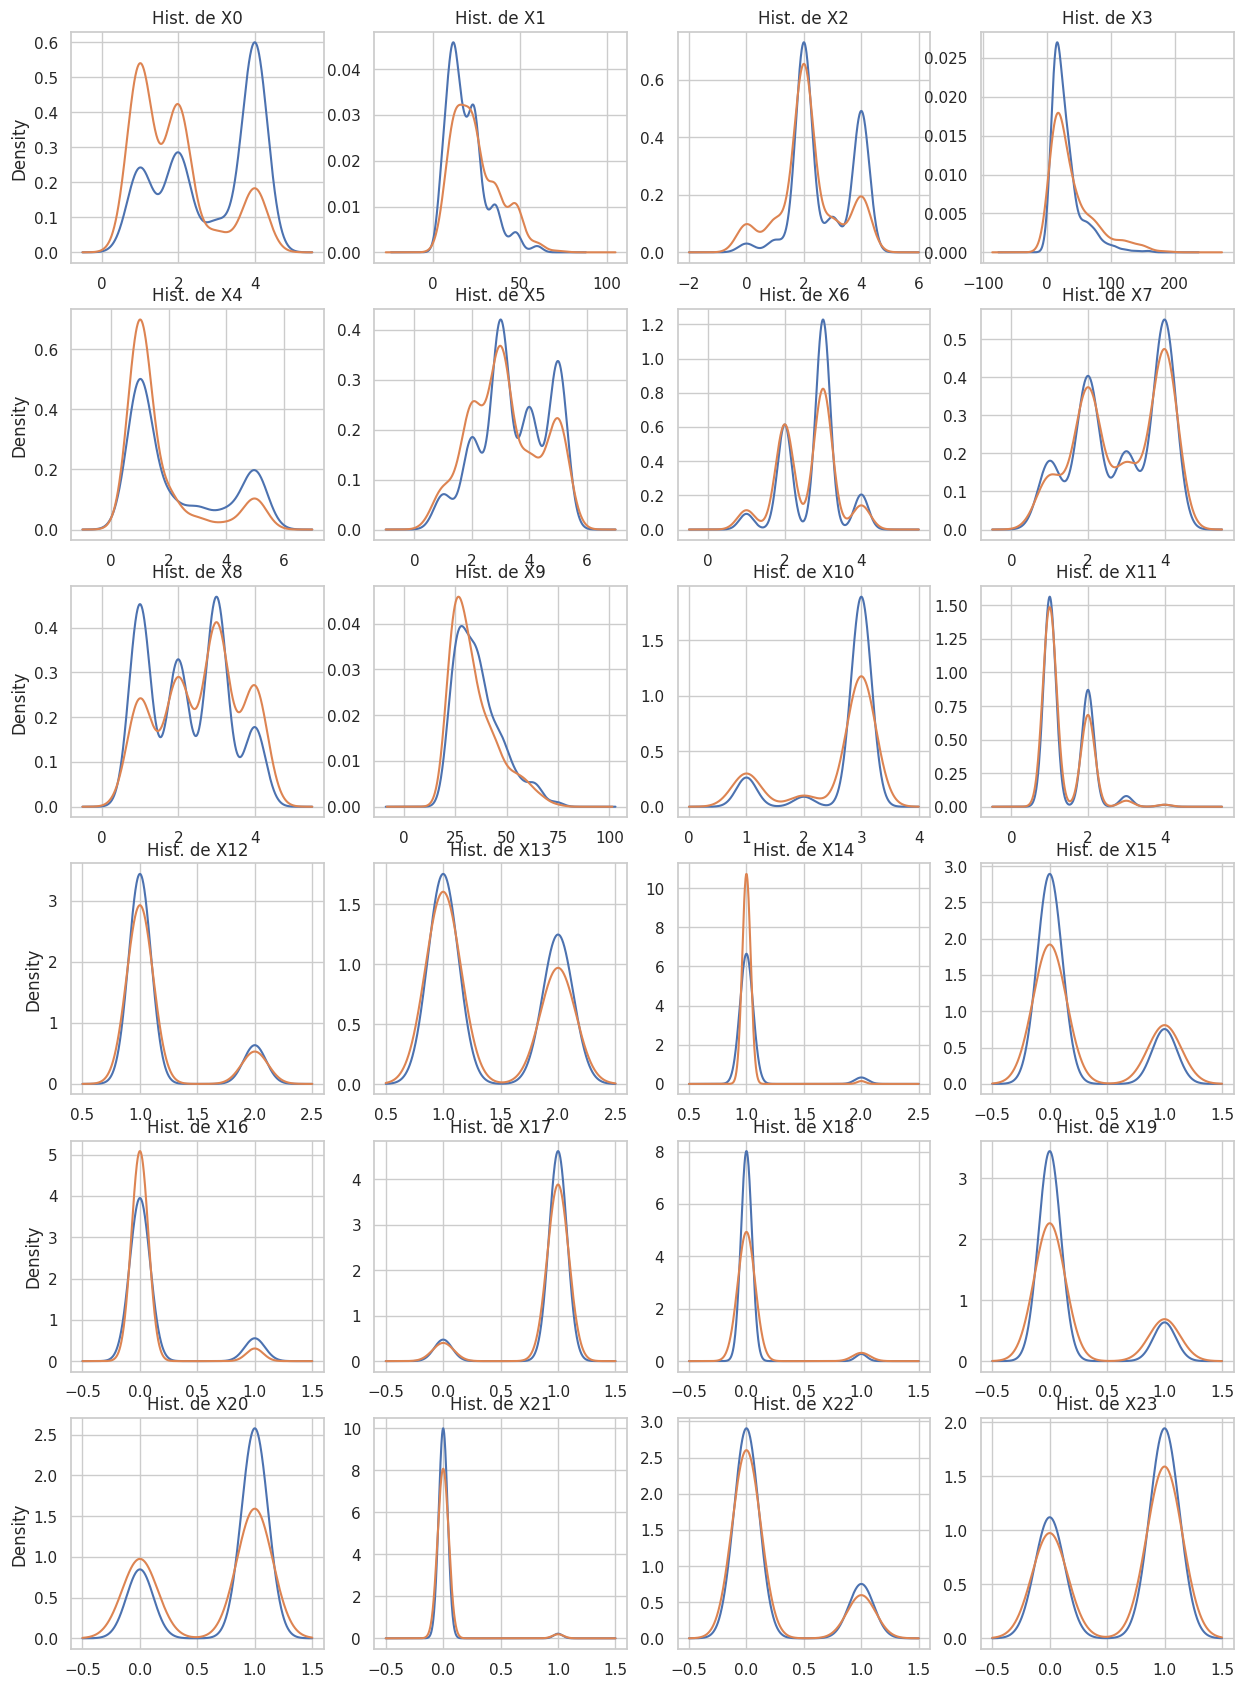

In [6]:
plt.figure(figsize=(15, 21))
n_cols_plot = 4
n_rows_plot = int(len(feature_names) / n_cols_plot)
for i,n in enumerate(feature_names):
    plt.subplot(n_rows_plot, n_cols_plot, i+1)
    aux = 'Density' if i%n_cols_plot == 0 else ''
    df.groupby('Class')[n].plot(kind='kde', title='Hist. de '+n)
    plt.ylabel(aux)

## Procesamiento

En ocasiones, en lugar de utilizar modelos más complejos, es más útil invertir más tiempo en el procesamiento de los datos para conseguir mejores resultados.

En este apartado vas a investigar mecanismos para preparar los datos y obtener (en principio) mejores resultados: construcción y selección de atributos, preprocesamiento (detección de outliers, missing values, centrado y escalado).

Razona por qué decides probar o ignorar alguno de estos métodos, y cómo cambian los resultados al aplicarlos (puedes crear tantas celdas como consideres oportunas).
Usa tablas, gráficas y código, según sea necesario, para ilustrar tus observaciones.

**Comentarios sobre datos**

En la página donde hemos extraído los datos ([https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data))), podemos extraer conclusiones muy relevantes sobre los datos y la información que nos proporcionan. Analizaremos principalmente el conjunto de datos numéricos, ya que es con este conjunto de datos codificados con los que entrenaremos los modelos y obtendremos sus predicciones.

Nuestro conjunto de datos tiene $25$ columnas. La última hace referencia a la clase del dato (default o no). Tenemos más columnas que número de atributos ($20$), debido a que algunos atributos son nominales no ordenados y precisan de codificación one hot. Haremos referencia a estos más adelante para interpretarlos correctamente. Tenemos una muestra de $1000$ datos para estas $25$ columnas, como podemos observar en la tabla descriptiva de los atributos, sin ningún *NA*.

De estos $1000$ datos, el $30\%$ de ellos hacen default, lo cual es una proporción demasiado elevada. A la hora de separar los datos en entrenamiento y test, así como para la selección de hiperparámetros mediante validación cruzada, deberemos estratificar los datos para mantener esta proporción de clases en todos los conjuntos.

Además, como podemos leer en la página web, es peor clasificar a un cliente como bueno siendo malo, que clasificar a uno malo cuando es bueno. Esto es lógico, ya que la pérdida sufrida es mucho mayor si un cliente hace default frente a los intereses perdidos por no dar un crédito.

Tras un análisis de los distintos atributos y la información que proporcionan a la hora de predecir si un cliente hará o no default, trateremos de determinar si alguno de ellos es prescindible para los distintos modelos, ya que $25$ atributos puede ser un número demasiado elevado de atributos y estaríamos introduciendo ruido para los modelos, aumentando el error de generalización.

**Descripción de atributos**

En primer lugar, identificaremos cada columna con su atributo correspondiente y su tipo:

*  **$X_0$: Status of existing checking account (Nominal Ordenado)**
    * 1: `... < 0 DM`
    * 2: `0 <= ... < 200 DM`
    * 3: `... >= 200 DM / salary assignments for at least 1 year`
    * 4: `no checking account`

*  **$X_1$: Duration in month (Numérico)**
    * Valor numérico directo (meses).

*  **$X_2$: Credit history (Nominal Ordenado)**
    * 0: `no credits taken / all paid`
    * 1: `all credits at this bank paid`
    * 2: `existing credits paid back duly`
    * 3: `delay in paying off`
    * 4: `critical account`

*  **$X_3$: Credit amount (Numérico)**
    * Valor numérico (cantidad de crédito). Este dato está escalado, los datos están divididos entre $100$ y redondeados al alza o a la baja, dependiendo del tercer dígito del dato original.

*  **$X_4$: Savings account/bonds (Nominal Ordenado)**
    * 1: `... < 100 DM`
    * 2: `100 <= ... < 500 DM`
    * 3: `500 <= ... < 1000 DM`
    * 4: `.. >= 1000 DM`
    * 5: `unknown/ no savings account`

*  **$X_5$: Present employment since (Nominal Ordenado)**
    * 1: `unemployed`
    * 2: `... < 1 year`
    * 3: `1 <= ... < 4 years`
    * 4: `4 <= ... < 7 years`
    * 5: `.. >= 7 years`

*  **$X_6$: Personal status and sex (Nominal no Ordenado)**
    * 1: `male : divorced/separated`
    * 2: `female : divorced/separated/married`
    * 3: `male : single`
    * 4: `male : married/widowed`

*  **$X_7$: Present residence since (Numérico)**
    * 1, 2, 3, 4: Años en la residencia actual.

*  **$X_8$: Property (Nominal Ordenado)**
    * 1: `real estate`
    * 2: `building society savings...`
    * 3: `car or other`
    * 4: `unknown / no property`

* **$X_9$: Age in years (Numérico)**
    * Valor numérico directo.

* **$X_{10}$: Other installment plans (Nominal no Ordenado)**
    * 1: `bank`
    * 2: `stores`
    * 3: `none`

* **$X_{11}$: Number of existing credits at this bank (Numérico)**
    * Valor numérico.

* **$X_{12}$: Number of people being liable (Numérico)**
    * Valor numérico.

* **$X_{13}$: Telephone (Nominal Ordenado)**
    * 1: `none`
    * 2: `yes`

* **$X_{14}$: Foreign worker (Nominal Ordenado)**
    * 1: `yes`
    * 2: `no`

***Nota:** El atributo original "Installment rate" no aparece en este dataset numérico, probablemente ya haya sido eliminado por ser irrelevante.*

 **Atributos "One-Hot Encoded" (Nominales no Ordenados):**

**Grupo Purpose ($X_{15}, X_{16}$)**
* **$X_{15}$:** 1 si el propósito es **Car (new)**, 0 si no.
* **$X_{16}$:** 1 si el propósito es **Car (used)**, 0 si no.

    *(Si $X_{15}=0$ y $X_{16}=0$, el propósito es otro de los listados en la web).*

**Grupo Other debtors ($X_{17}, X_{18}$)**

* **$X_{17}$:** 1 si **None** (sin deudores), 0 si hay otro.
* **$X_{18}$:** 1 si **Co-applicant**, 0 si no.

    *(Si $X_{17}=0$ y $X_{18}=0$, entonces es **Guarantor**).*

**Grupo Housing ($X_{19}, X_{20}$)**
* **$X_{19}$:** 1 si **Rent** (alquiler), 0 si no.
* **$X_{20}$:** 1 si **Own** (propio), 0 si no.

    *(Si $X_{19}=0$ y $X_{20}=0$, entonces es **For Free**).*

**Grupo Job ($X_{21} - X_{23}$)**
* **$X_{21}$:** 1 si **Unemployed / Unskilled - non-resident**.
* **$X_{22}$:** 1 si **Unskilled - resident**.
* **$X_{23}$:** 1 si **Skilled employee / official**.

    *(Si $X_{21}=0, X_{22}=0$ y $X_{23}=0$, entonces es **Management / Self-employed / Highly qualified**).*


Vamos a explicar por qué decidimos que los atributos nominales sean ordenados o no, sobretodo para aquellos que tengan una clasificación más dudosa. Los atributos numéricos los identifica la propia página, lo que nos facilita su clasificación. Asimismo, los atributos que ya están codificados de manera One Hot, también se consideran ya organizados (como nominales no ordinarios).




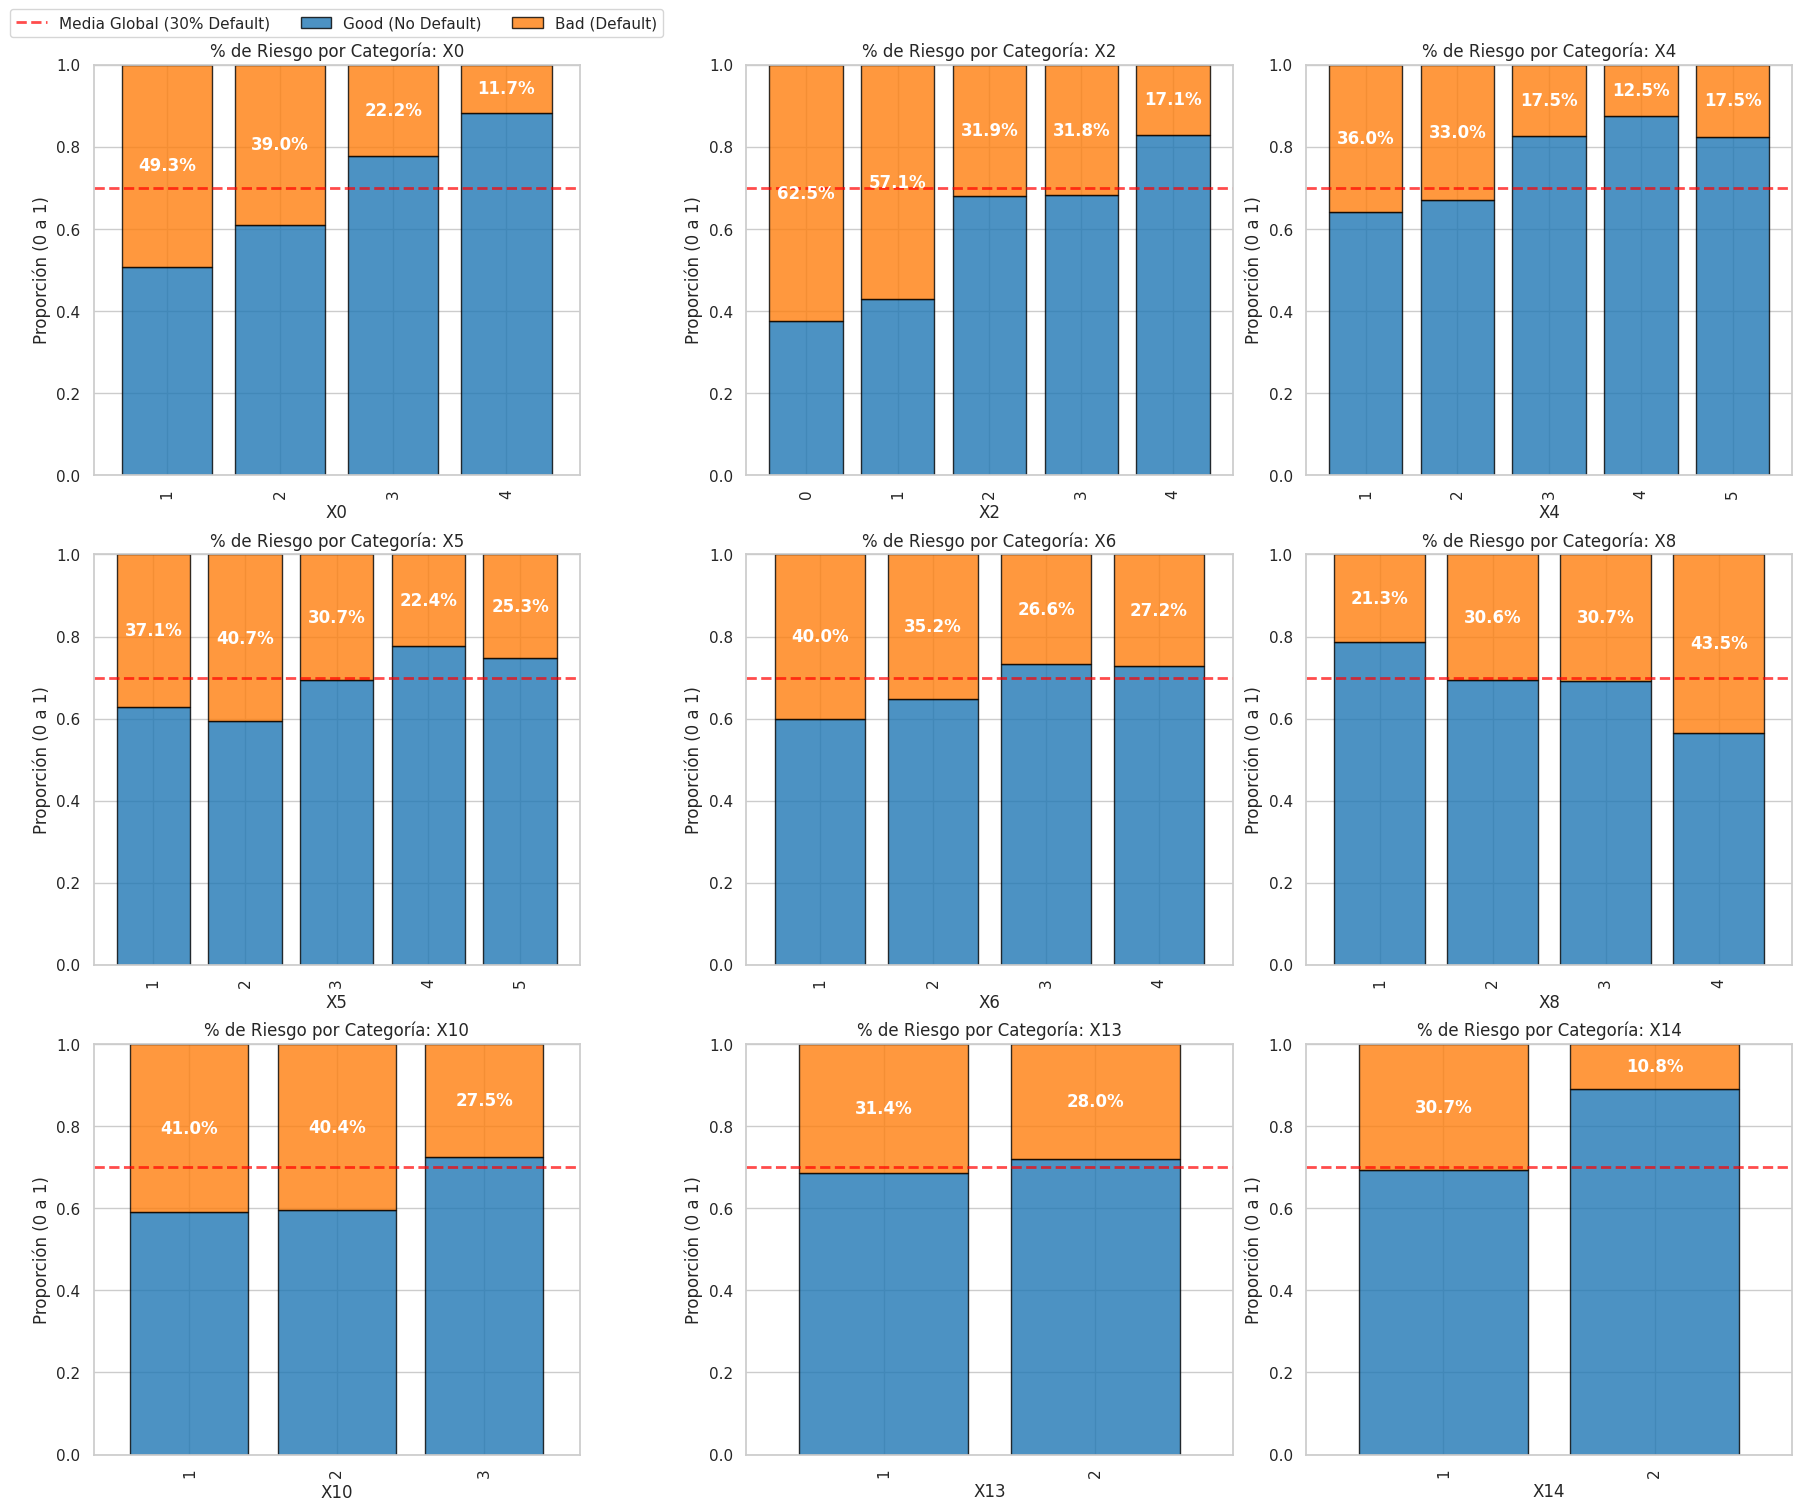

In [7]:
cols_interes = [f'X{i}' for i in [0, 2, 4, 5, 6, 8, 10, 13, 14]]

plot_risk(df, cols_interes)

* **Nominales Ordenados:** Hemos seleccionado $X_0, X_2, X_4, X_5, X_8, X_{13}$ y $X_{14}$. Se puede observar una relación monótona descendiente en el $\%$ de default de los atributos, precisamente por eso son ordinales, además de la lógica semántica comparativa. $X_0$ es el ejemplo más claro de ser un nominal ordenado, tanto por su distribución como por la información que aporta. Probablemente sea el atributo más relevante a la hora de clasificar un cliente como default o no, lo comprobaremos más adelante. Cabe destacar el caso de $X_2$, donde la relación es inversa a la lógica (empeora el historial crediticio y disminuye el $\%$ de default). Esto se debe a que el banco, si concede el préstamo a alguien que tiene un mal historial, es porque está realmente seguro de que le pagará gracias a los niveles de los demás atributos, obteniendo así está relación "ilógica" a priori. Para $X_5$, no observamos esta relación descendiente comentada, sin embargo, es evidentemente un ordinal (es peor estar desempleado que llevar más de 7 años trabajando), por eso mantenemos la clasificación. Esto mismo sucede para $X_4$, donde el último dato tiene un ligero aumento de $\%$ de default con respecto a los demás. En cuanto a $X_{13}$ y $X_{14}$, que podrían parecer no ordinales en primera instancia, hemos decidido clasificarlos de esta manera, ya que esta base de datos es de los años $70$ y tener teléfono en esta época puede ser un signo de poder adquisitivo y normalmente los inmigrantes tienen menos dinero que los nacionales. Además, los gráficos apoyan esta tesis. Sobre $X_8$, podría ser semánticamente no ordinal; sin embargo, es más solvente (probablemente) alguien con una casa en propiedad frente a alguien con un coche o sin ninguna propiedad. Por este motivo, añadido a la relación vista en el gráfico, lo incluimos en el grupo ordinal.

* **Nominales no Ordenados:** Hemos seleccionado $X_6$ y $X_{10}$. En estos casos, aunque se pueda establecer una ligera relación monótona en las variables, es evidente que no son ordinales (sexo y estado civil y otro tipo de planes de pago). Deberemos codificarlos usando "One-Hot-Encoding".

Es relevante conocer la distribución de estos atributos, como acabamos de mostrar, para poder eliminar alguno de la muestra (por ejemplo, el sexo del cliente, no parece un atributo muy relevante a la hora de predecir el default), así como para determinar si es necesario escalar los datos o no, según el tipo de atributo. Por ejemplo, los atributos "One-Hot-Encoded", no los podemos escalar, ya que su significado está en la lectura de varias columnas seguidas, no en la columna por sí misma.

Deberemos escalar los datos numéricos y los datos nominales ordenados, para no distorsionar las distancias entre los datos y que el modelo considere más o menos importantes algunos atributos.

Asimismo, los datos nominales no ordenados que no están codificados en varias columnas, deberemos aplicarles la codificación One Hot. Por ejemplo $X_6$, es un nominal no ordenado, ya que en principio no tiene un orden de peor a mejor, a la hora de hacer default, ser hombre o mujer, casado o no. Sin embargo, tal y como está codificado en esta base de datos, el modelo podría interpretar que es mejor ser hombre casado (codificado con el 4) que ser hombre divorciado (codificado con el 1), lo cual no tiene un sentido económico.

**Comentario sobre histogramas**

Los histogramas nos dan una información muy reveladora sobre cada atributo, teniendo en cuenta la naturaleza de cada uno, como hemos descrito previamente.

Sobre la relevancia de un atributo a la hora de predecir o no el default, cuanto más separadas estén las líneas de default y de no default en el histograma, mejor. Esto ayudará al modelo a identificar patrones en ese atributo que propician (o no) el impago.

Fijémonos en el histograma de $X_0$: claramente hay más defaults cuanto menor valor tiene el atributo (menos dinero en la cuenta corriente). Además, este atributo parece muy fiable a la hora de poder predecir el default, el dinero que tenga el cliente en el banco. Podría considerarse como el atributo más importante, lo comprobaremos más adelante.

En los histogramas de $X_{12}$ y $X_{13}$, por ejemplo, no existe ninguna dependencia aparente entre los valores de los atributos y el impago o no: ambas líneas son prácticamente idénticas. Además, esto es lógico, ya que $X_{12}$ es el número de personas a las que mantener y $X_{13}$ tener teléfono o no, atributos que no deberían tener mucha relación con el default del cliente.

Además, si la mayoría de los datos están en un único punto, la variable apenas aporta información, para que el clasificador pueda discernir entre "buenos" y "malos" para distintos valores de ese atributo. Esto, de nuevo, es lo que pasa en $X_{12}$, por lo que podría parecer un buen candidato a eliminar. Dentro de este enfoque, debemos tener cuidado con los atributos codificados en varias columnas, ya que no podemos realizar la misma interpretación.

Aunque en menor medida, también nos pueden servir para detectar outliers, como en el histograma de $X_3$ (cantidad de crédito), donde se puede comprobar que la mayoría de los créditos son de poco dinero, aunque hay algunos donde se solicitan cantidades más altas (y tienen también más defaults). Esta distribución es claramente asimétrica, lo que puede distorsionar a los algoritmos de redes neuronales o vecinos próximos para su correcto ajuste. Utilizaremos como escalado de los datos numéricos y nominales ordinales `RobustScaler`, como consecuencia de esto, para lidiar con los datos atípicos o con las colas pesadas (fenómenos típicos al tratar con datos financieros). Este escalador utiliza la mediana para centrar los datos, que es más robusta que la media que utiliza `StandardScaler`.


**Comentario sobre Baseline Model Performance**

Antes de realizar el preprocesamiento de los datos, efectuado con los argumentos previamente descritos, efectuaremos un último comentario de interés sobre la información otorgada en la página web de los datos.

Tras los comentarios sobre los datos, hay dos gráficas denominadas _Baseline Model Performance_, donde compara la exactitud y precisión de distintos clasificadores para esta base de datos, empleando la arquitectura e hiperparámetros de esos modelos dados por defecto en sus respectivas librerías.

Relevantes para nuestra práctica, muestra la calidad de los árboles de decisión y de las redes neuronales. De nuevo, sobre sus modelos base (sin modificar hiperparámetros ni arquitectura), por lo que no podemos tratar estos resultados como absolutos. Sin embargo, dado que nuestro objetivo es encontrar el mejor clasificador para nuestros datos, estas gráficas nos pueden resultar reveladoras.

Estas gráficas dan un rango de valores, ya que dependiendo de la separación entre `train` y `test`, el clasificador funcionará mejor o peor. Asimismo, comentar que _accuracy_ refleja el porcentaje de veces que el modelo acierta clasificando bien ambas clases y _precision_ el porcentaje de aciertos que tiene el modelo a la hora de clasificar un dato como default.

En ambas categorías, los árboles de decisión predicen mucho mejor que las redes neuronales. Esta información es interesante, comprobaremos por nosotros mismos en nuestro trabajo si obtenemos los mismos resultados, así como si modificando los hiperparámetros y la arquitectura, eligiendo la óptima para cada modelo, las redes neuronales son capaces de batir a los árboles de decisión (y a los vecinos próximos, por supuesto, el tercer clasificador que analizaremos).

**Preprocesamiento**

In [8]:
# Generación de los datos de train y test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
# Pasamos de 1=Good, 2=Bad  --->  0=Good, 1=Default

if y_train.max() > 1:
    y_train = np.where(y_train == 2, 1, 0)
    y_test = np.where(y_test == 2, 1, 0)
    print("Target normalizado a 0 y 1.")

Target normalizado a 0 y 1.


In [10]:
# Escalado de datos

# Atributos a codificar

features_to_encode = ['X6', 'X10']

# Atributos ya codificados

features_passthrough = [f'X{i}' for i in range(15, 24)]

# Atributos a escalar

features_to_scale = [col for col in X_train.columns
                     if col not in features_to_encode and col not in features_passthrough]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_to_scale),
        ('cat', categorical_transformer, features_to_encode),
        ('pass', 'passthrough', features_passthrough)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("\nDimensiones después del preprocesamiento:", X_train_proc.shape)




Dimensiones después del preprocesamiento: (800, 27)


In [11]:
X_train_proc.describe()

,X0,X1,X2,X3,X4,X5,X7,X8,X9,X11,...,X10_3,X15,X16,X17,X18,X19,X20,X21,X22,X23
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,...,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000
mean,0.193333,0.230833,0.280625,0.352079,0.555625,0.203750,-0.085000,0.181250,0.165982,0.407500,...,0.811250,0.242500,0.105000,0.91125,0.042500,0.180000,0.71250,0.020000,0.197500,0.638750
std,0.419402,0.984777,0.543766,1.059841,0.786124,0.596495,0.555685,0.525589,0.788951,0.567315,...,0.391555,0.428863,0.306745,0.28456,0.201853,0.384428,0.45288,0.140088,0.398362,0.480663
min,-0.333333,-1.166667,-1.000000,-0.792079,0.000000,-1.000000,-1.000000,-0.500000,-1.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,-0.333333,-0.500000,0.000000,-0.366337,0.000000,0.000000,-0.500000,-0.500000,-0.428571,0.000000,...,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000,1.00000,0.000000,0.000000,1.000000
75%,0.666667,0.500000,1.000000,0.633663,1.000000,1.000000,0.500000,0.500000,0.571429,1.000000,...,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000,1.00000,0.000000,0.000000,1.000000
max,0.666667,3.500000,1.000000,5.386139,2.000000,1.000000,0.500000,1.000000,3.000000,3.000000,...,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


Hemos añadido el `Imputer` en el `Pipeline` para hacer el código más robusto ante la llegada de nuevos datos o ante "missing values". Si mañana llega un cliente con un dato en blanco, el modelo rellenará ese hueco con la mediana y seguirá funcionando. A pesar de que no tenemos _NAs_ en este modelo, conviene incluirlo.

**Relevancia de atributos**

Analizamos la relevancia para la predicción de los atributos sirviéndonos de la correlación $r$.

Vale la pena mencionar que en este gráfico tan solo estamos midiendo correlaciones, es decir, relaciones lineales. En otras palabras, si en nuestro modelo existen estructuras de dependencia "no lineales", que por ejemplo sí capta la red neuronal, la correlación podría subestimarlas.

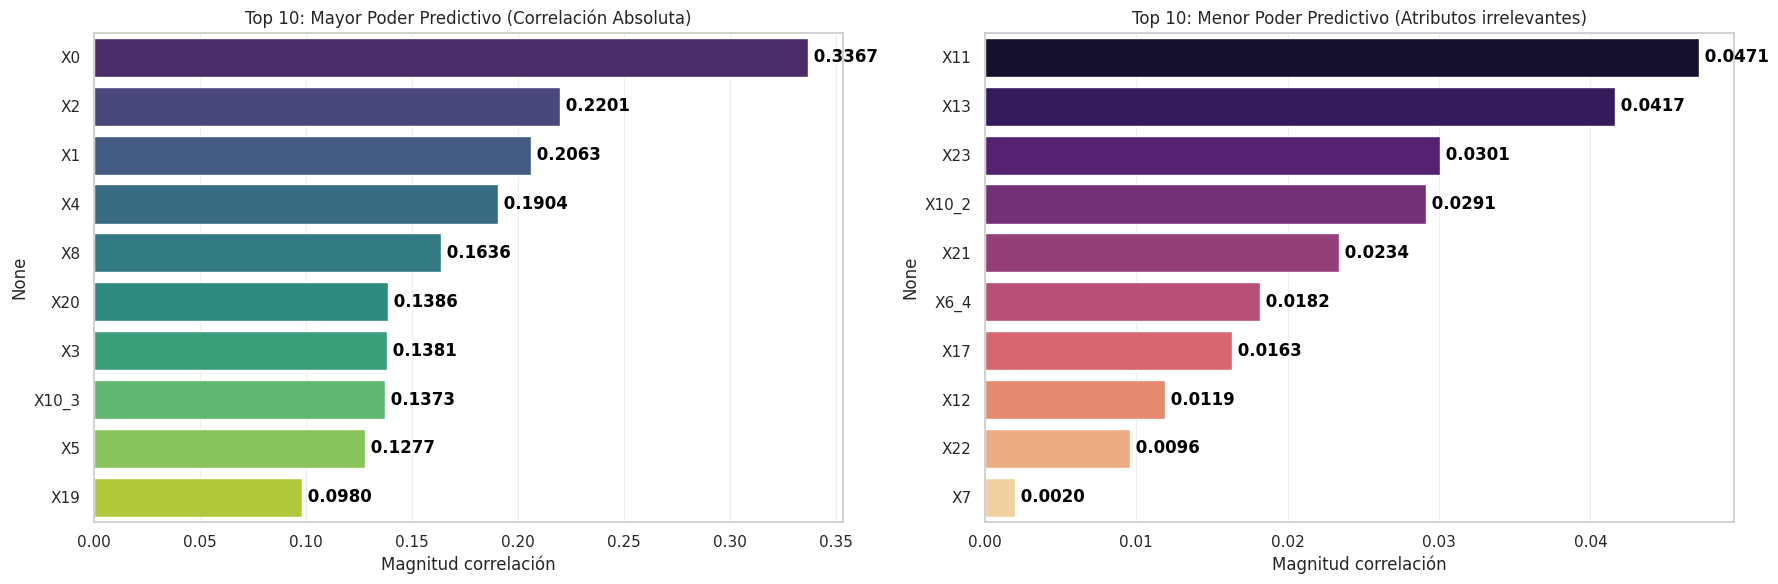

--- Valores exactos: Top 10 Mayor Correlación ---
X0       0.336676
X2       0.220105
X1       0.206301
X4       0.190440
X8       0.163582
X20      0.138617
X3       0.138139
X10_3    0.137324
X5       0.127664
X19      0.097980
dtype: float64

--- Valores exactos: Top 10 Menor Correlación ---
X11      0.047149
X13      0.041655
X23      0.030096
X10_2    0.029134
X21      0.023380
X6_4     0.018185
X17      0.016306
X12      0.011905
X22      0.009592
X7       0.001965
dtype: float64


In [12]:
# Convertimos y_train a pandas para poder graficar

y_series = pd.Series(y_train, index=X_train_proc.index)

# Calculamos la correlación absoluta
correlations = X_train_proc.corrwith(y_series).abs().sort_values(ascending=False)

# Seleccionamos los atributos con mayor y menor correlación
top_5 = correlations.head(10)
bottom_5 = correlations.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    x=top_5.values,
    y=top_5.index,
    palette='viridis',
    hue=top_5.index,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Top 10: Mayor Poder Predictivo (Correlación Absoluta)')
axes[0].set_xlabel('Magnitud correlación')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(top_5.values):
    axes[0].text(v, i, f' {v:.4f}', color='black', va='center', fontweight='bold')

sns.barplot(
    x=bottom_5.values,
    y=bottom_5.index,
    palette='magma',
    hue=bottom_5.index,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Top 10: Menor Poder Predictivo (Atributos irrelevantes)')
axes[1].set_xlabel('Magnitud correlación')
axes[1].grid(axis='x', alpha=0.3)


for i, v in enumerate(bottom_5.values):
    axes[1].text(v, i, f' {v:.4f}', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Valores exactos: Top 10 Mayor Correlación ---")
print(top_5)
print("\n--- Valores exactos: Top 10 Menor Correlación ---")
print(bottom_5)

Vemos cómo el atributo con mayor correlación con el default es $X_0$, la cuenta corriente, como habíamos vaticinado. Otras variables relevantes son el historial crediticio, la duración del crédito, la cuenta de ahorros y las propiedades del cliente. Todas estas variables tienen un sentido financiero relevante, evidentemente.

En cuanto al historial crediticio, ya habíamos visto que descendía la probabilidad de default a medida que empeoraba la calidad crediticia, por tanto tendrá correlación negativa (en el gráfico se muestran sus valores absolutos): cuanta peor calidad crediticia, mayores exigencias del banco para dar el préstamo y por eso la intensidad de default disminuye.

Por otro lado, la cuenta de ahorros puede estar muy correlacionada con la cuenta corriente. A continuación realizaremos un análisis multivariante para medir la correlación entre los distintos atributos y poder eliminar aquellos que no aporten información nueva.

En cuanto a los valores con menor correlación con el default, debemos ser ciertamente cautos con la interpretación, debido a que hay atributos extendidos en varias columnas debido a la codificación One Hot. Por ejemplo, $X10\_2$ está en el grupo de las que menos explican el default, sin embargo, su pareja $X10\_3$ está en el grupo de las que más explican. Por tanto, no podemos eliminar este atributo.

Teniendo en cuenta esto, tenemos $3$ atributos candidatos a eliminar según esta métrica:

* $X_7:$ Explica un $0.01\%$ del default. Este debemos eliminarlo, hace referencia al número de años que lleva el cliente en la residencia actual (tampoco tiene mucho sentido que explique el impago).

* $X_{12}:$ Ya habíamos presupuesto que este atributo, el número de personas bajo manutención, tampoco influía mucho en el estudio. Ahora lo comprobamos cuantitativamente, con una correlación del $1.2\%$, lo debemos eliminar también.

* $X_{21}$, $X_{22}$ y $X_{23}:$ Estas columnas se refieren a la codificación del atributo nominal no ordinario que hace referencia a la situación laboral del cliente (desempleado, empleado sin cualificación y empleado cualificado). La columna que más explica de las $3$ es $X_{23}$, con una correlación muy baja (del $3\%$) con el default, rozando el límite para poder eliminar a un atributo. Sin embargo, tal vez esta métrica empeore los resultados para este tipo de atributos, al medir la contribución por columna y no para el atributo en general. Además, tiene sentido financiero que la situación laboral del cliente influya en el impago o no del crédito. Por tanto, mantendremos este atributo.

Al resto de columnas que aparecen dentro del Top $10$ con menor correlación, les sucede lo mismo, forman parte de atributos nominales no ordinarios codificados en varias columnas, por lo que no los eliminaremos. En cuanto a $X_{11}$ y $X_{13}$,  el número de créditos que tienen con el banco y si tiene teléfono o no, son atributos que tienen una correlación baja (entre el $4$ y el $5\%$), aunque no es tan baja como para los demás. Aunque podrían eliminarse también, ya que tampoco tienen especial sentido económico para que el cliente no pague la deuda, no vamos a ser tan inflexibles con los atributos y los vamos a mantener en el conjunto de datos.

In [13]:
# Eliminamos los atributos irrelevantes

cols_to_drop = ['X7', 'X12']

X_train_sel = X_train_proc.drop(columns=cols_to_drop, errors='ignore')
X_test_sel = X_test_proc.drop(columns=cols_to_drop, errors='ignore')

Cabe destacar que estas variables eliminadas no tenían capacidad predictiva lineal en el modelo, tal vez sí la tuvieran no lineal y las redes neuronales podrían aprender de ello. Emplearemos ambos conjuntos de datos a la hora de entrenar nuestros modelos para ver si hemos hecho una buena poda con estos dos atributos o no.

**Análisis de Multicolinealidad**

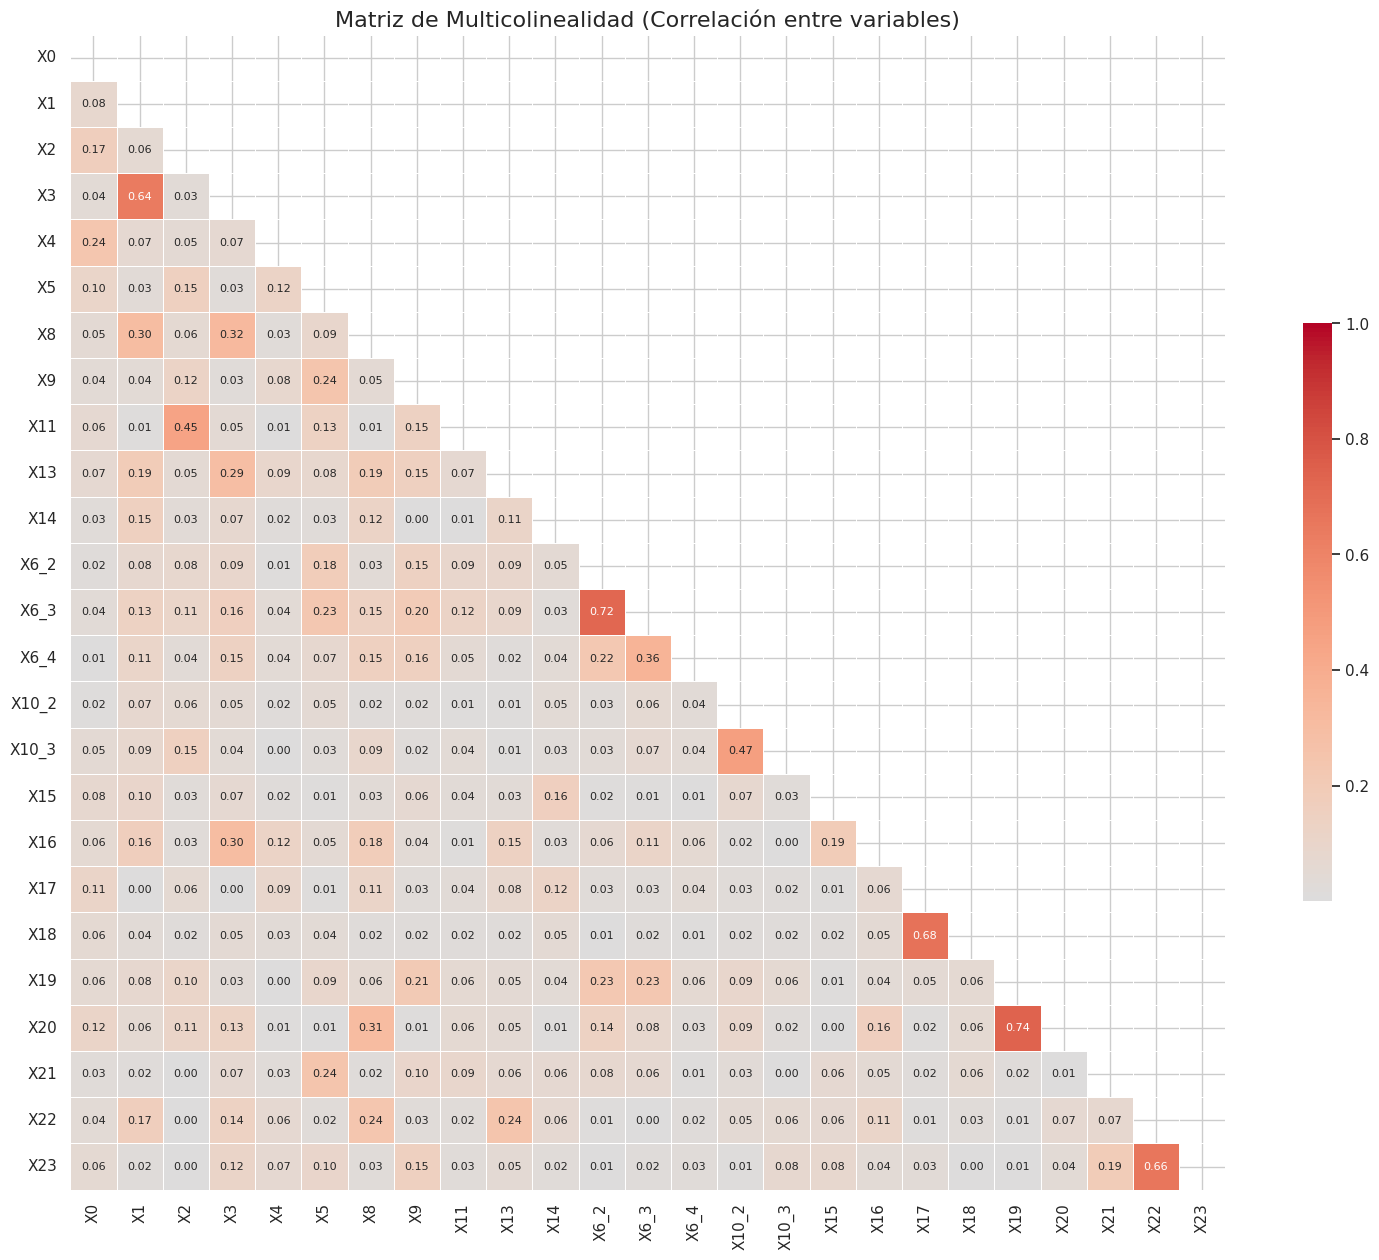

--- Pares de variables con alta colinealidad (> 0.7) ---
X6_3 - X6_2: 0.7247
X20 - X19: 0.7376


In [14]:
# Calculamos la matriz de correlación sobre los datos con
# las variables X7 y X12 ya eliminadas. Efectuar el análisis
# de multicolinealidad sobre los datos con todos los atributos
# no aportaría información relevante, simplemente la correlación
# que tienen estos atributos (ya eliminados) con otros.

corr_matrix = X_train_sel.corr().abs()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmax=1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)

plt.title('Matriz de Multicolinealidad (Correlación entre variables)', fontsize=16)
plt.show()

print("--- Pares de variables con alta colinealidad (> 0.7) ---")
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.7:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            score = corr_matrix.iloc[i, j]
            high_corr_pairs.append((colname_i, colname_j, score))
            print(f"{colname_i} - {colname_j}: {score:.4f}")

if not high_corr_pairs:
    print("No se encontraron pares con correlación > 0.7")

Observando la matriz de correlación entre las distintas columnas, observamos que no hay problemas de multicolinealidad relevantes en nuestro conjunto de datos. Las correlaciones más altas se dan para columnas que forman parte del mismo atributo, lo que es normal y no debería preocuparnos.

Cabe destacar la correlación entre $X_3$, la cantidad de crédito, y $X_1$, la duración del préstamo. Tiene una correlación bastante elevada ($64\%$), algo lógico teniendo en cuenta la naturaleza de los atributos (cuanto mayor sea el préstamo, más tiempo necesitarás para devolverlo). Además, $X_1$ era de las variables más explicativas para el default, mientras que $X_3$ tenía la mitad de capacidad lineal para predecir el default, por tanto, podríamos plantearnos el eliminarla.

Sin embargo, dada que no es una correlación cercana a $1$, a pesar de ser sorprendentemente elevada, vamos a optar por ser cautos y mantenerla en la base de datos, eliminando en exclusiva las variables $X_7$ y $X_{12}$.

## Entrenamiento de un modelo y evaluación de su calidad usando 5-fold cross validation

La siguiente celda entrena un modelo y lo evalúa en varias particiones training-test diferentes de los datos. El resultado es un score medio junto a su desviación estándar. El tipo de modelo (Naïve Bayes / árbol de decisión / knn/ regresión logística / red neuronal) y parámetros empleados deberán ser seleccionados para que dicho resultado sea el mejor posible.

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
# otros clasificadores

clf = KNeighborsClassifier(n_neighbors=1) # DecisionTreeClassifier(max_depth=3)
scores = cross_val_score(clf, X, y, cv=10) # 10-fold cross-validation
print('Precisión en cada una de las particiones: ', scores)
print('Estimación de la precisión por validación cruzada: {:.2f} +/- {:.2f}'.format(scores.mean(), scores.std()))

Precisión en cada una de las particiones:  [0.65 0.62 0.72 0.66 0.63 0.71 0.59 0.7  0.62 0.66]
Estimación de la precisión por validación cruzada: 0.66 +/- 0.04


## Responde aquí a las siguientes preguntas:

* Haz una gráfica que muestre la dependencia de la precisión de un clasificador de vecinos próximos con el número de vecinos. Si es más conveniente, utiliza gráficas en escala logarítmica para alguno de los ejes (`semilogx`, `semilogy`, `loglog`).
* Utilizando los conceptos de sub- y sobreajuste:
    * Comenta los resultados cuando el número de vecinos es pequeño.
    * Comenta los resultados cuando el número de vecinos es grande.
    * Explica el significado del valor de la precisión cuando el número de vecinos toma el valor mayor posible.
* ¿Cuál es la mejor precisión que se alcanza con k-nn y para qué k (valor de `n_neighbours`)?
* ¿Cuál es la mejor precisión que se alcanza con un árbol de decisión y con qué profundidad máxima (valor de `max_depth`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con la profundidad máxima del árbol. Comenta los resultados.
* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con una sola capa oculta y con qué configuración (valor de `hidden_layer_sizes`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de nodos en la capa oculta. Comenta los resultados.
* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con varias capas ocultas y con qué configuración? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de capas ocultas, suponiendo constante el número de nodos en cada capa oculta. Comenta los resultados.
* Resume los resultados y conclusiones del estudio realizado.

**Además de gráficas, puede ser conveniente presentar los resultados en forma de tablas.**


## Procesamiento

En ocasiones, en lugar de utilizar modelos más complejos, es más útil invertir más tiempo en el procesamiento de los datos para conseguir mejores resultados.

En este apartado vas a investigar mecanismos para preparar los datos y obtener (en principio) mejores resultados: construcción y selección de atributos, preprocesamiento (detección de outliers, missing values, centrado y escalado).

Razona por qué decides probar o ignorar alguno de estos métodos, y cómo cambian los resultados al aplicarlos (puedes crear tantas celdas como consideres oportunas).
Usa tablas, gráficas y código, según sea necesario, para ilustrar tus observaciones.

## ¿Cómo se determina el valor de los hiperparámetros?

Para determinar el valor de los hiperparámetros de un modelo realizaremos una búsqueda en una rejilla. De entre los valores considerados seleccionaremos los que maximicen la estimación por validación cruzada (K = 10) de la tasa de acierto.

Adapta el código que encontrarás en
[https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py)
a este problema.

En los tutoriales
[https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html](
    https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
[https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
hay información sobre cada uno de los hiper-parámetros.
Puedes elegir el conjunto de hiperparametros en el que se realiza la optimización.
Antes de elegir la rejilla de hiperparámetros, asegúrate de que entiendes su para asegurarte que tiene sentido la búsqueda.

## ¿Cómo se estima el error de generalización?

Estimaremos el error de generalización de cada clasificador usando *Nested Cross Validation*.


Adapta el código que encontrarás en https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html para resolver este problema con una red neuronal.


## ¿Cuál es el mejor clasificador?

* De acuerdo con los resultados de los anteriores apartados, indica cuál es el mejor clasificador encontrado.
* ¿Cuáles son los valores de los hiperparámetros utilizados para configurar y entrenar tal  clasificador?
* ¿cuáles son los valores de los parámetros del clasificador entrenado?
* Proporciona una estimación del error de generalización por validación cruzada, así como de la incertidumbre de dicha estimación.


# FASE 1: ENTRENAMIENTO Y CROSS-VALIDATION

En el modelado del riesgo de crédito, la asimetría de los costes de clasificación es altísima. Un Falso Negativo (clasificar a un cliente moroso como buen pagador) implica soportar una pérdida llamada Loss Given Default (LGD) mientras que un Falso Positivo (rechazar a un buen pagador) tan solo conlleva un coste de oportunidad sobre el margen de intereses. Dado que el impacto de un default no detectado es bastante más grande que lo que perdemos (o dejamos de ganar) por no darle un préstamo a un buen pagador, la métrica por defecto de ``Accuracy`` no es adecuada en estos casos. Si usáramos Accuracy, la "función de utilidad" consistiría simplemente en "Maximizar aciertos totales". Sin embargo, optamos por maximizar el modelo sirviéndonos del F2-Score ($F_{\beta}$ con $\beta=2$), donde la función objetivo cambia a: "Maximiza la detección de defaults, aunque te equivoques un poco con los buenos". Esto prioriza el Recall (sensibilidad al riesgo) sobre la Precisión, actuando como una función de pérdida ponderada por el peso que le damos a equivocarnos, determinado. En este F-Score, el parámetro que entra en juego es el $\beta$, que sirve para cuantificar el "dolor" de equivocarnos con un cliente moroso de la siguiente manera:

$$\text{Peso} = \beta^2 = 2^2 = 4$$

En este caso, esto significa matemáticamente que no detectar un default para el banco, duele 4 veces más que rechazar a un cliente bueno. Esta métrica la usaremos para los 3 modelos, será nuestra vara de medir.


In [16]:
# Usamos F2-Score: Prioriza encontrar el fraude (Recall) sobre acertar buenos pagadores.
f2_scorer = make_scorer(fbeta_score, beta=2)

## A. KNN (K-NEIGHBORS CLASSIFIERS)

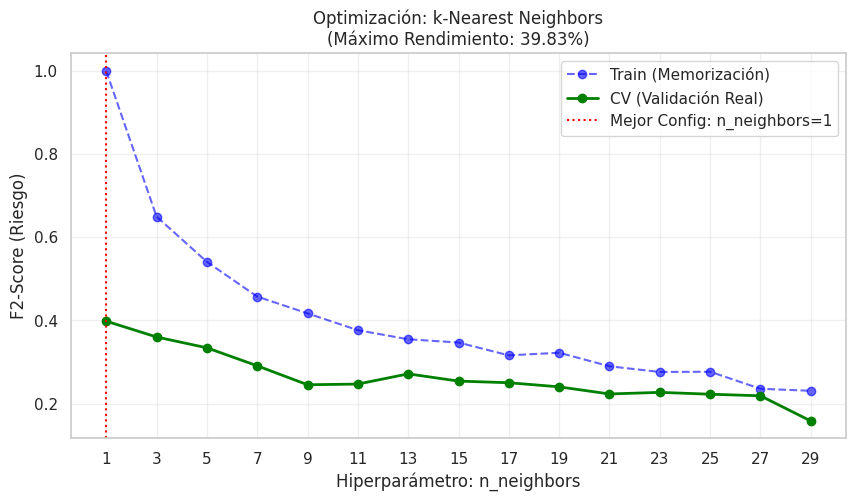

Ganador: n_neighbors = 1 -> F2: 39.83%



In [17]:
# KNN

# Búsqueda del mejor k por cross-validation. En impares.
rango_knn = list(range(1, 30, 2))

best_k = cross_validation(
    model_class=KNeighborsClassifier,
    param_name='n_neighbors',
    param_range=rango_knn,
    X=X_train_sel,
    y=y_train,
    static_params={'n_jobs': -1},
    model_name="k-Nearest Neighbors"
)

In [18]:
knn_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
rendimiento_cv(knn_model, f"k-NN (k={best_k})", X_train_sel, y_train)

RENDIMIENTO (CV): k-NN (k=1)
   - Defaults Identificados (TP):      91 de 240
   - Defaults No Detectados (FN):      149
   >>> Sensibilidad (Recall):          37.92%

B. Coste de oportunidad:
   - Falsos Positivos (Error Tipo I):  114
   - Cartera Solvente Total:           560
   >>> Tasa de Rechazo (Solventes):    20.36%


(np.float64(0.37916666666666665), np.float64(0.20357142857142857))

En el gráfico observamos que el óptimo técnico se alcanza con $k=1$, un claro indicador de sobreajuste donde el modelo memoriza el ruido idiosincrásico de los datos en lugar de aprender patrones generalizables. Al intentar mitigar esto aumentando el número de vecinos, el desbalanceo de clases provoca que la señal de los impagos quede ahogada estadísticamente por la mayoría solvente, un fallo estructural que se confirma drásticamente en el diagnóstico mediante validación cruzada: el algoritmo arroja un Recall del 37,92%, lo que implica que el banco asumiría pérdidas en casi el 62% de los casos de morosidad real, descuidando por completo su capital regulado por la normativa de Basilea.

Además, esta falta de seguridad ni siquiera garantiza eficiencia comercial, pues el modelo rechaza erróneamente al 20,36% de la cartera solvente (Falsos Positivos). La causa principal de este problema se explica por la naturaleza geométrica del k-NN y el exceso de dimensionalidad; al tratar 20 variables en el espacio, se diluye la importancia de factores o atributos en la $X$ que son más importantes que otros (y por tanto han de tener más peso en la capacidad predictiva) como por ejemplo el estado de la cuenta corriente frente a variables demográficas irrelevantes, volviendo la distinción entre defaults y solvencia prácticamente aleatoria y descartando al modelo de vecinos cercanos como una opción viable.

## B. ÁRBOLES DE DECISIÓN

Nota: *Aunque hemos controlado el sobreajuste mediante prepoda (max_depth), una alternativa más robusta podría ser el Cost Complexity Pruning (ccp_alpha), que permite crecer el árbol y luego podarlo.*

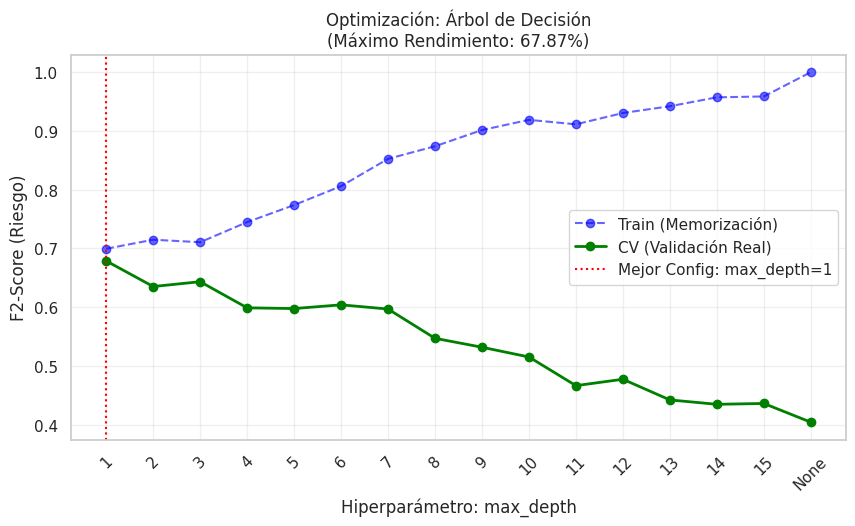

Ganador: max_depth = 1 -> F2: 67.87%



In [19]:
# ARBOLES DE DECISION

# Rango de profundidades a probar (None para infinito)
rango_arbol = list(range(1, 16)) + [None]

best_depth_real = cross_validation(
                        model_class=DecisionTreeClassifier,
                        param_name='max_depth',
                        param_range=rango_arbol,
                        X=X_train_sel,
                        y=y_train,
                        static_params={'criterion': 'entropy', 'class_weight': 'balanced', 'random_state': 42},
                        model_name="Árbol de Decisión"
                    )

In [20]:
dt_model = DecisionTreeClassifier(
    max_depth=best_depth_real,
    criterion='entropy',
    class_weight='balanced',
    random_state=42
)
rendimiento_cv(dt_model, f"Árbol (Depth={best_depth_real})", X_train_sel, y_train)

RENDIMIENTO (CV): Árbol (Depth=1)
   - Defaults Identificados (TP):      193 de 240
   - Defaults No Detectados (FN):      47
   >>> Sensibilidad (Recall):          80.42%

B. Coste de oportunidad:
   - Falsos Positivos (Error Tipo I):  273
   - Cartera Solvente Total:           560
   >>> Tasa de Rechazo (Solventes):    48.75%


(np.float64(0.8041666666666667), np.float64(0.4875))

A diferencia del enfoque pasivo del k-NN, en los Árboles de Decisión intervenimos directamente en la función de coste mediante el hiperparámetro ``class_weight='balanced'``, penalizando desproporcionadamente el error en impagos para alinearnos con la aversión al riesgo ($\beta=2$) que se alinea más con los objetivos del banco.

Esta configuración fuerza al algoritmo a abandonar la vaguedad de predecir la clase mayoritaria, resultando el árbol final en una arquitectura óptima de profundidad 1, lo que sugiere que la señal de riesgo en este dataset no es compleja, sino que está dominada por una única variable diferenciadora.

Los resultados del diagnóstico son contundentes; la sensibilidad se dispara hasta un 80,42% (capturando 193 de 240 defaults), superando drásticamente al k-NN y actuando como una barrera eficaz contra la insolvencia; sin embargo, esta simplicidad estructural impone un coste de oportunidad enorme; ya que la falta de matices en la predicción (o nodos más profundos en el árbol) provoca el rechazo erróneo del 48,75% de los clientes solventes (273 falsos positivos).


Ante este comportamiento tan polarizado (máxima seguridad, mínima flexibilidad) basado en una sola regla, surge la pregunta inevitable: ¿Cuál es esa única variable capaz de segregar al 80% de los morosos? Procedemos a visualizar la estructura del árbol.

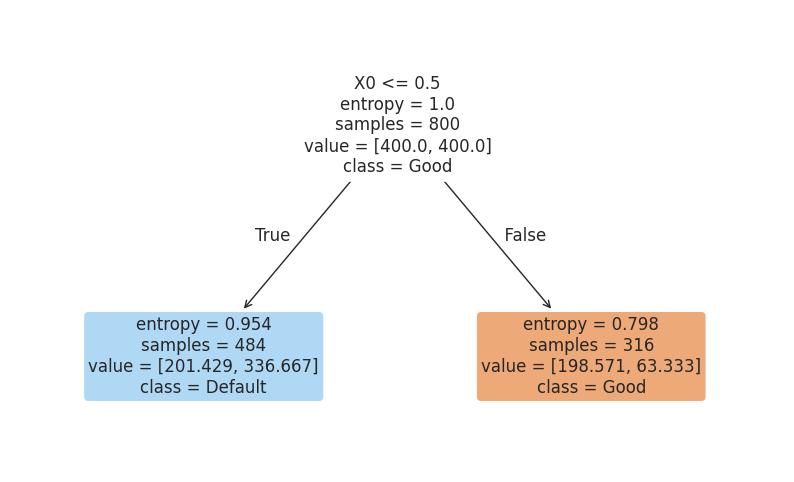

In [21]:
# VISUALIZACIÓN DEL ÁRBOL GANADOR
plt.figure(figsize=(10, 6))

plot_tree(dt_model.fit(X_train_sel, y_train),
          feature_names=X_train_sel.columns,
          class_names=['Good', 'Default'],
          filled=True,
          rounded=True,
          fontsize=12)

plt.show()

El árbol óptimo revela que la variable $X_0$ (Checking Account Status) es según este árbol, la única pregunta que realmente importa. Al operar bajo tanta aversión al riesgo ($\beta=2$), el algoritmo ha decidido ignorar la edad o el historial crediticio para centrarse en una única pregunta: la liquidez inmediata ($X_0$). El árbol ha aprendido que, sin dinero en la cuenta la probabilidad de default es inminente, siendo este el único atributo contra la insolvencia.

Si bien esta estrategia actúa como un detector muy potente contra el riesgo, carece de flexibilidad comercial: es un algoritmo que rechaza indiscriminadamente a clientes sólidos o con buenas rentas solo por tener la cuenta bancaria a 0 (no tendría por qué hacerlo ya que podrían existir casos particulares así), y por tanto el banco se está perdiendo muchos préstamos que podrían ser beneficiosos a costa de detectar los morosos.

En este caso, el banco previene el default, pero las potenciales ganancias disminuyen drásticamente. Esta rigidez valida la necesidad urgente de evolucionar hacia modelos más complejos capaces de aportar la inteligencia necesaria para detectar clientes morosos pero sin tener tanto coste de oportunidad al dejar escapar clientes buenos, como las redes neuronales.



## C. REDES NEURONALES

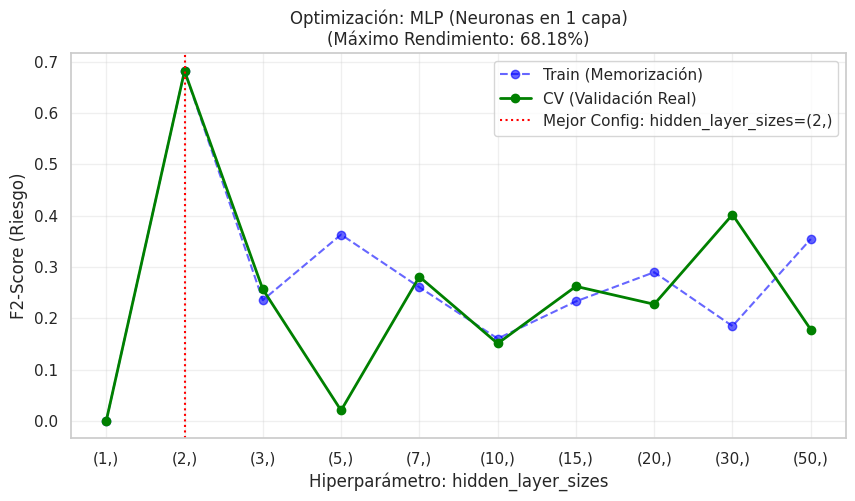

Ganador: hidden_layer_sizes = (2,) -> F2: 68.18%

La arquitectura base para la Fase 3 será de (2,) neuronas.


In [22]:
# REDES NEURONALES

# A. NUMEROS DE NEURONAS
h_values = [1, 2, 3, 5, 7, 10, 15, 20, 30, 50]

param_range_neurons = [(h,) for h in h_values]

best_h= cross_validation(
            model_class=MLPClassifier,
            param_name='hidden_layer_sizes',
            param_range=param_range_neurons,
            X=X_train_sel,
            y=y_train,
            static_params={
                'alpha': 0.0001,
                'max_iter': 2000,
                'early_stopping': True,
                'random_state': 42
            },
            model_name="MLP (Neuronas en 1 capa)"
        )

print(f"La arquitectura base para la Fase 3 será de {best_h} neuronas.")

In [23]:
mlp_winner = MLPClassifier(
    hidden_layer_sizes=best_h,
    alpha=0.0001,
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

rendimiento_cv(mlp_winner, f"MLP ({best_h[0]} Neuronas)", X_train_sel, y_train)

RENDIMIENTO (CV): MLP (2 Neuronas)
   - Defaults Identificados (TP):      240 de 240
   - Defaults No Detectados (FN):      0
   >>> Sensibilidad (Recall):          100.00%

B. Coste de oportunidad:
   - Falsos Positivos (Error Tipo I):  560
   - Cartera Solvente Total:           560
   >>> Tasa de Rechazo (Solventes):    100.00%


(np.float64(1.0), np.float64(1.0))

Se repite el estudio utilizando el clasificador ``MLPClassifier``, manteniendo la métrica F2-Score para priorizar la detección de morosos, algo crucial aquí ya que, a diferencia de los Árboles, esta red neuronal no admite el parámetro de ponderación de clases (class_weight).

Para controlar la complejidad y evitar el sobreajuste, hemos configurado una penalización L2 (``alpha=1e-4``) y activado el early_stopping para detener el entrenamiento si el rendimiento se estanca. El resultado de la validación cruzada señala que la arquitectura óptima es muy simple, de tan solo 2 neuronas, logrando un sorprendente Recall del 100%.

Sin embargo, al comprobar este resultado, descubrimos que el modelo ha caído en una solución trivial: ante la presión de no dejar escapar ningún impago, ha decidido clasificar todas las solicitudes como "Default". Esto explica por qué no falla nunca (detecta los 60 morosos), pero a cambio comete un error comercial fatal: rechaza también a los 140 clientes solventes (Tasa de Rechazo del 100%). Aunque esta estrategia elimina totalmente el riesgo de impago, conlleva el colapso de la actividad comercial del banco, lo que nos indica que una sola capa no tiene la capacidad suficiente para distinguir entre buenos y malos, obligándonos a probar arquitecturas más profundas en el siguiente paso.

Contrario a la teoría general, la gráfica muestra un comportamiento inusual: el aumento de la complejidad (número de neuronas) no se traduce en una mejora progresiva del ajuste. El Espejismo del Óptimo ($h=2$): Observamos un pico aislado de rendimiento con 2 neuronas ($F2 \approx 68\%$). Como confirmó el análisis anterior, esto no es inteligencia real, sino una estrategia degenerada de rechazo total (Recall 100%, Tasa de Rechazo 100%). En otras palabras, en el cálculo por descenso de gradiente la red neuronal se ha "atascado" en un mínimo local al no tener la suficiente capacidad de aprendizaje.  

Al aumentar el número de neuronas, esperaríamos que la línea azul (Train) subiera hacia 1.0 (memorización). Sin embargo, tanto el entrenamiento como la validación colapsan a niveles de $F2 < 0.40$. Esto evidencia que una red de una sola capa, incluso con 50 neuronas, es incapaz de encontrar una frontera de decisión válida para estos datos. La red no está sobreajustando (memorizando ruido), simplemente no está convergiendo a ninguna solución útil más allá de la trivial.

Conclusión: Este gráfico certifica que la arquitectura de una sola capa está agotada. No es un problema de número de neuronas, sino de profundidad. Es imprescindible dar el salto a arquitecturas multicapa para permitir a la red neuronal aprender y no colapsar en mínimos locales.

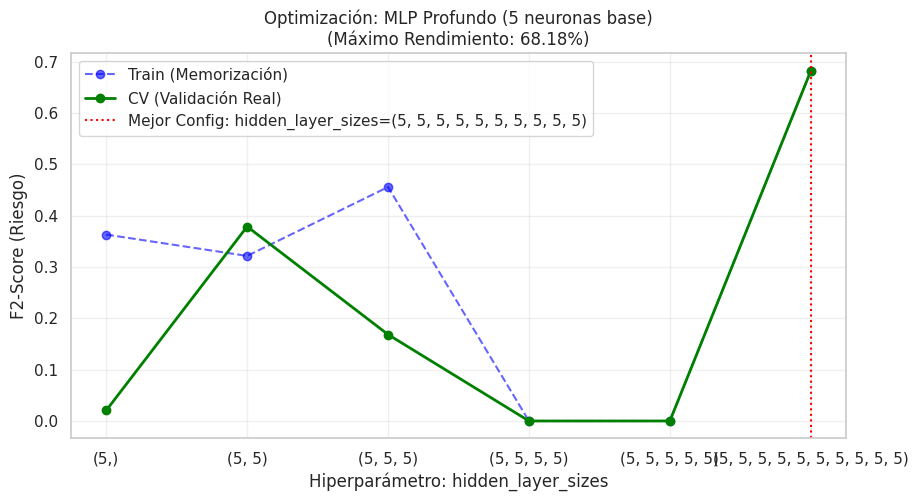

Ganador: hidden_layer_sizes = (5, 5, 5, 5, 5, 5, 5, 5, 5, 5) -> F2: 68.18%



In [24]:
# REDES NEURONALES
# B. NÚMERO DE CAPAS

# USAMOS 5 NEURONAS POR CAPA COMO EJEMPLO
best_neurons = 5

# 1. Definimos cuántas capas queremos probar
n_layers_list = [1, 2, 3, 4, 5, 10]

param_range_layers = [tuple([best_neurons] * n) for n in n_layers_list]

best_struct = cross_validation(
                    model_class=MLPClassifier,
                    param_name='hidden_layer_sizes',
                    param_range=param_range_layers,
                    X=X_train_sel,
                    y=y_train,
                    static_params={
                        'alpha': 0.0001,
                        'max_iter': 2000,
                        'early_stopping': True,
                        'random_state': 42
                    },
                    model_name=f"MLP Profundo ({best_neurons} neuronas base)"
                )

In [25]:
mlp_deep_winner = MLPClassifier(
    hidden_layer_sizes=best_struct,
    alpha=1e-4,
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

rendimiento_cv(
    mlp_deep_winner,
    f"MLP Profundo {best_struct}",
    X_train_sel,
    y_train
)

RENDIMIENTO (CV): MLP Profundo (5, 5, 5, 5, 5, 5, 5, 5, 5, 5)
   - Defaults Identificados (TP):      240 de 240
   - Defaults No Detectados (FN):      0
   >>> Sensibilidad (Recall):          100.00%

B. Coste de oportunidad:
   - Falsos Positivos (Error Tipo I):  560
   - Cartera Solvente Total:           560
   >>> Tasa de Rechazo (Solventes):    100.00%


(np.float64(1.0), np.float64(1.0))

La exploración de arquitecturas profundas (Deep Learning) mediante la adición de capas ocultas, pero manteniendo una anchura fija de 5 neuronas, ha vuelto a surgir en una inestabilidad en lugar de mejorar la capacidad de aprendizaje de la red neuronal.

El gráfico evidencia un comportamiento errático donde el rendimiento colapsa a cero en arquitecturas intermedias, recuperándose únicamente en el extremo de 10 capas con un F2-Score del 68.18%. Sin embargo, en los resultados mostrados por nuestra función ``rendimiento_vc`` se muestra que este "óptimo" es, nuevamente, otro falso positivo.

La red de 10 capas ha convergido exactamente a la misma solución trivial que la red de una sola capa, logrando un Recall del 100% mediante el rechazo indiscriminado de toda la cartera (Tasa de Rechazo del 100%). Este fracaso sugiere que una anchura de 5 neuronas actúa como un cuello de botella informativo; al forzar a los datos a pasar por tantas capas estrechas, la señal de gradiente se desvanece o se distorsiona, impidiendo el aprendizaje de características complejas.

En conclusión, aumentar la profundidad sin ajustar la anchura es inútil; el modelo sigue sin dar ningún crédito como solución para no tener defaults, algo que a efectos comerciales carecería de sentido. Esto hace necesario avanzar hacia una optimización conjunta (GridSearch) que busque el equilibrio entre anchura (capacidad de representación) y profundidad (capacidad de abstracción), descartando estas arquitecturas fijas que a nivel de negocio no tienen sentido práctico.


# FASE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS

In [26]:
# OPTIMIZACIÓN DE HIPERPARÁMETROS
# 1. REJILLA (GRID)

# A. K-NN
knn = KNeighborsClassifier()

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 11, 15, 31],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# B. ÁRBOL DE DECISIÓN (Sin scaler)
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

param_grid_dt = {
    "criterion": ["entropy", "gini"],     # Entropy o Gini
    "max_depth": [3, 5, 10, 20, None],    # Escala con saltos
    "min_samples_leaf": [1, 5, 20, 50]    # Hojas
}

# C. REDES NEURONALES
mlp = MLPClassifier(max_iter=1000, random_state=42, early_stopping=True)

param_grid_mlp = {
    "hidden_layer_sizes": [
        (50,),              # 1 Capa
        (50, 30),           # Profundidad media
        (100, 50, 25)       # Deep Learning
    ],
    "alpha": [0.0001, 0.001, 0.01],  # Regularización L2
    "learning_rate_init": [0.001, 0.01]
}

# 2. MODELOS A OPTIMIZAR
searches = [
    ("k-NN", knn, param_grid_knn),
    ("Árbol de Decisión", dt, param_grid_dt),
    ("Redes Neuronales", mlp, param_grid_mlp),
]

best_summary = []
best_models_objects = {}

for name, model, grid in searches:
    gs = GridSearchCV(
        estimator=model,
        param_grid=grid,
        cv=10,
        scoring=f2_scorer,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    gs.fit(X_train_sel, y_train)

    best_summary.append({
        "Modelo": name,
        "F2_Score_CV": gs.best_score_,
        "Mejores_Parametros": gs.best_params_
    })

    best_models_objects[name] = gs.best_estimator_

# 3. RESULTADOS
print("\nRANKING TÉCNICO (F2-SCORE)")
results_df = pd.DataFrame(best_summary).sort_values("F2_Score_CV", ascending=False)
display(results_df)

# 4. EVALUAMOS A LOS GANADORES
print("\nEVALUACIÓN A LOS GANADORES")

for name, model in best_models_objects.items():
    rendimiento_cv(model, f"OPTIMIZED {name}", X_train_sel, y_train)

Fitting 10 folds for each of 24 candidates, totalling 240 fits
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Fitting 10 folds for each of 18 candidates, totalling 180 fits

RANKING TÉCNICO (F2-SCORE)


,Modelo,F2_Score_CV,Mejores_Parametros
1,Árbol de Decisión,0.684976,"{'criterion': 'entropy', 'max_depth': 5, 'min_..."
2,Redes Neuronales,0.524892,"{'alpha': 0.0001, 'hidden_layer_sizes': (100, ..."
0,k-NN,0.411290,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei..."



EVALUACIÓN A LOS GANADORES
RENDIMIENTO (CV): OPTIMIZED k-NN
   - Defaults Identificados (TP):      94 de 240
   - Defaults No Detectados (FN):      146
   >>> Sensibilidad (Recall):          39.17%

B. Coste de oportunidad:
   - Falsos Positivos (Error Tipo I):  83
   - Cartera Solvente Total:           560
   >>> Tasa de Rechazo (Solventes):    14.82%
RENDIMIENTO (CV): OPTIMIZED Árbol de Decisión
   - Defaults Identificados (TP):      185 de 240
   - Defaults No Detectados (FN):      55
   >>> Sensibilidad (Recall):          77.08%

B. Coste de oportunidad:
   - Falsos Positivos (Error Tipo I):  200
   - Cartera Solvente Total:           560
   >>> Tasa de Rechazo (Solventes):    35.71%
RENDIMIENTO (CV): OPTIMIZED Redes Neuronales
   - Defaults Identificados (TP):      121 de 240
   - Defaults No Detectados (FN):      119
   >>> Sensibilidad (Recall):          50.42%

B. Coste de oportunidad:
   - Falsos Positivos (Error Tipo I):  70
   - Cartera Solvente Total:           560
   >>> 

# RESULTADOS DE LA OPTIMIZACIÓN (GRID SEARCH):

## 1. KNN:

Como veíamos previsible, vecinos cercanos resulta ser el peor modelo para detectar defaults con un $F2=41,13\%$. La mejor configuración de hiperparámetros que ha encontrado el optimizador es:

- ``k = 3``
- ``distance = manhattan``
- ``weights = uniform``

El KNN es un modelo "perezoso", tan solo se dedica a memorizar los datos del entrenamiento y no es capaz de captar patrones en los clientes que dan default. Además, al aumentar el número de atributos $X$, y más tras hacer ``One-Hot-Encoding`` y convertir variables categóricas en muchas columnas de ceros y unos, el espacio se vuelve inmensamente grande. Matemáticamente, la distancia entre cualquier par de puntos tiende a igualarse; por tanto los "vecinos más cercanos" ya no son realmente similares ni tienen ningún parecido razonable, simplemente son los que están "menos lejos" en una nube de muchísimos puntos.

Conclusión: k-NN funciona bien cuando todas las variables son numéricas, tienen importancia similar y dimensiones bajas. En este tipo de problemas (datos desbalanceados y con muchas variables categóricas), el k-NN no sabe ignorar lo que no importa ni diferenciar lo que sí importa. De hecho, algo tan simple como tirar una moneda al aire tendría daría mejor resultado para detectar defaults que vecinos cercanos (50\% > 41,13\%). Descartamos totalmente este modelo para problemas de este tipo.

## 2. ÁRBOL DE DECISIÓN

El Árbol de Decisión es el modelo ganador por una amplia diferencia, alcanzando un F2-Score del 68,50%. La configuración óptima para detectar defaults y la generalización es:

- ``max_depth = 5``
- ``min_samples_leaf = 5``
- ``criterion = entropy``
- ``class_weight = balanced``

A diferencia del KNN, el Árbol actúa como un filtro selectivo. Ha demostrado capacidad para ignorar las variables irrelevantes y centrarse en las señales fuertes. El uso de ``class_weight='balanced'`` ha sido el factor crítico, ya que este obliga al algoritmo a operar con una "aversión al riesgo" extrema, penalizando fuertemente los errores en clientes morosos y priorizando su detección (Recall = 77\%) sobre la tasa de aciertos.

Además, la optimización ha corregido el comportamiento del modelo inicial (donde teníamos un árbol de profundidad 1, que solo miraba la liquidez). Al permitir una profundidad de 5 y exigir un mínimo de 5 clientes por hoja el modelo ha evolucionado, ya no solo aplica la regla de distinguir a los clientes por el saldo en su cuenta bancaria, sino que ha aprendido matices secundarios (probablemente historial o empleo) para recuperar clientes, creando reglas de riesgo estadísticamente robustas.

Conclusión: Mientras que el KNN no era capaz de aprender el problema, el Árbol ha logrado entenderlo. Aunque sigue siendo un modelo conservador (sacrifica rechazar a clientes buenos para garantizar el menor número de morosos posibles), su rendimiento valida que el riesgo de crédito en este dataset sigue reglas lógicas y jerárquicas, no geométricas como k-NN.


## 3. REDES NEURONALES

Las redes neuronales ocupan el segundo lugar con un F2 = $52,49\%$. El hallazgo crítico está en la arquitectura ganadora:

- ``hidden_layer_sizes: (100, 50, 25)``
- ``alpha: 0.0001``
- ``learning_rate_init: 0.01``

Hemos optado por optimizar también el parámetro ``alpha``, (regularización L2). Este parámetro es fundamental para evitar que los pesos de la red exploten y causen oscilaciones numéricas, el valor óptimo es de $\alpha = 0.0001$.

Aquí observamos un cambio fundamental respecto a la Fase 1. Mientras que las redes simples colapsaban (rechazando al 100% de los clientes), esta arquitectura profunda y ancha (Deep Learning) ha logrado desbloquear el aprendizaje. El modelo ha conseguido reducir la Tasa de Rechazo al mínimo del grupo (12,50%), convirtiéndose en el mejor modelo en cuanto a menor coste de oportunidad. Sin embargo, paga un precio alto en seguridad: su Recall es del 50,42%.

Conclusión: La complejidad de 3 capas ha servido para solucionar el problema del rechazo masivo, pero sin un mecanismo como ``class_weight``, la red sigue priorizando demasiado la clase mayoritaria (los buenos pagadores), dejando escapar a la mitad de los morosos. Es un modelo prometedor, pero insuficiente para un perfil de riesgo $\beta=2$.

A continuación, vamos a representar cómo sería este árbol de decisión ganador con los hiperparámetros resultados de la optimización;

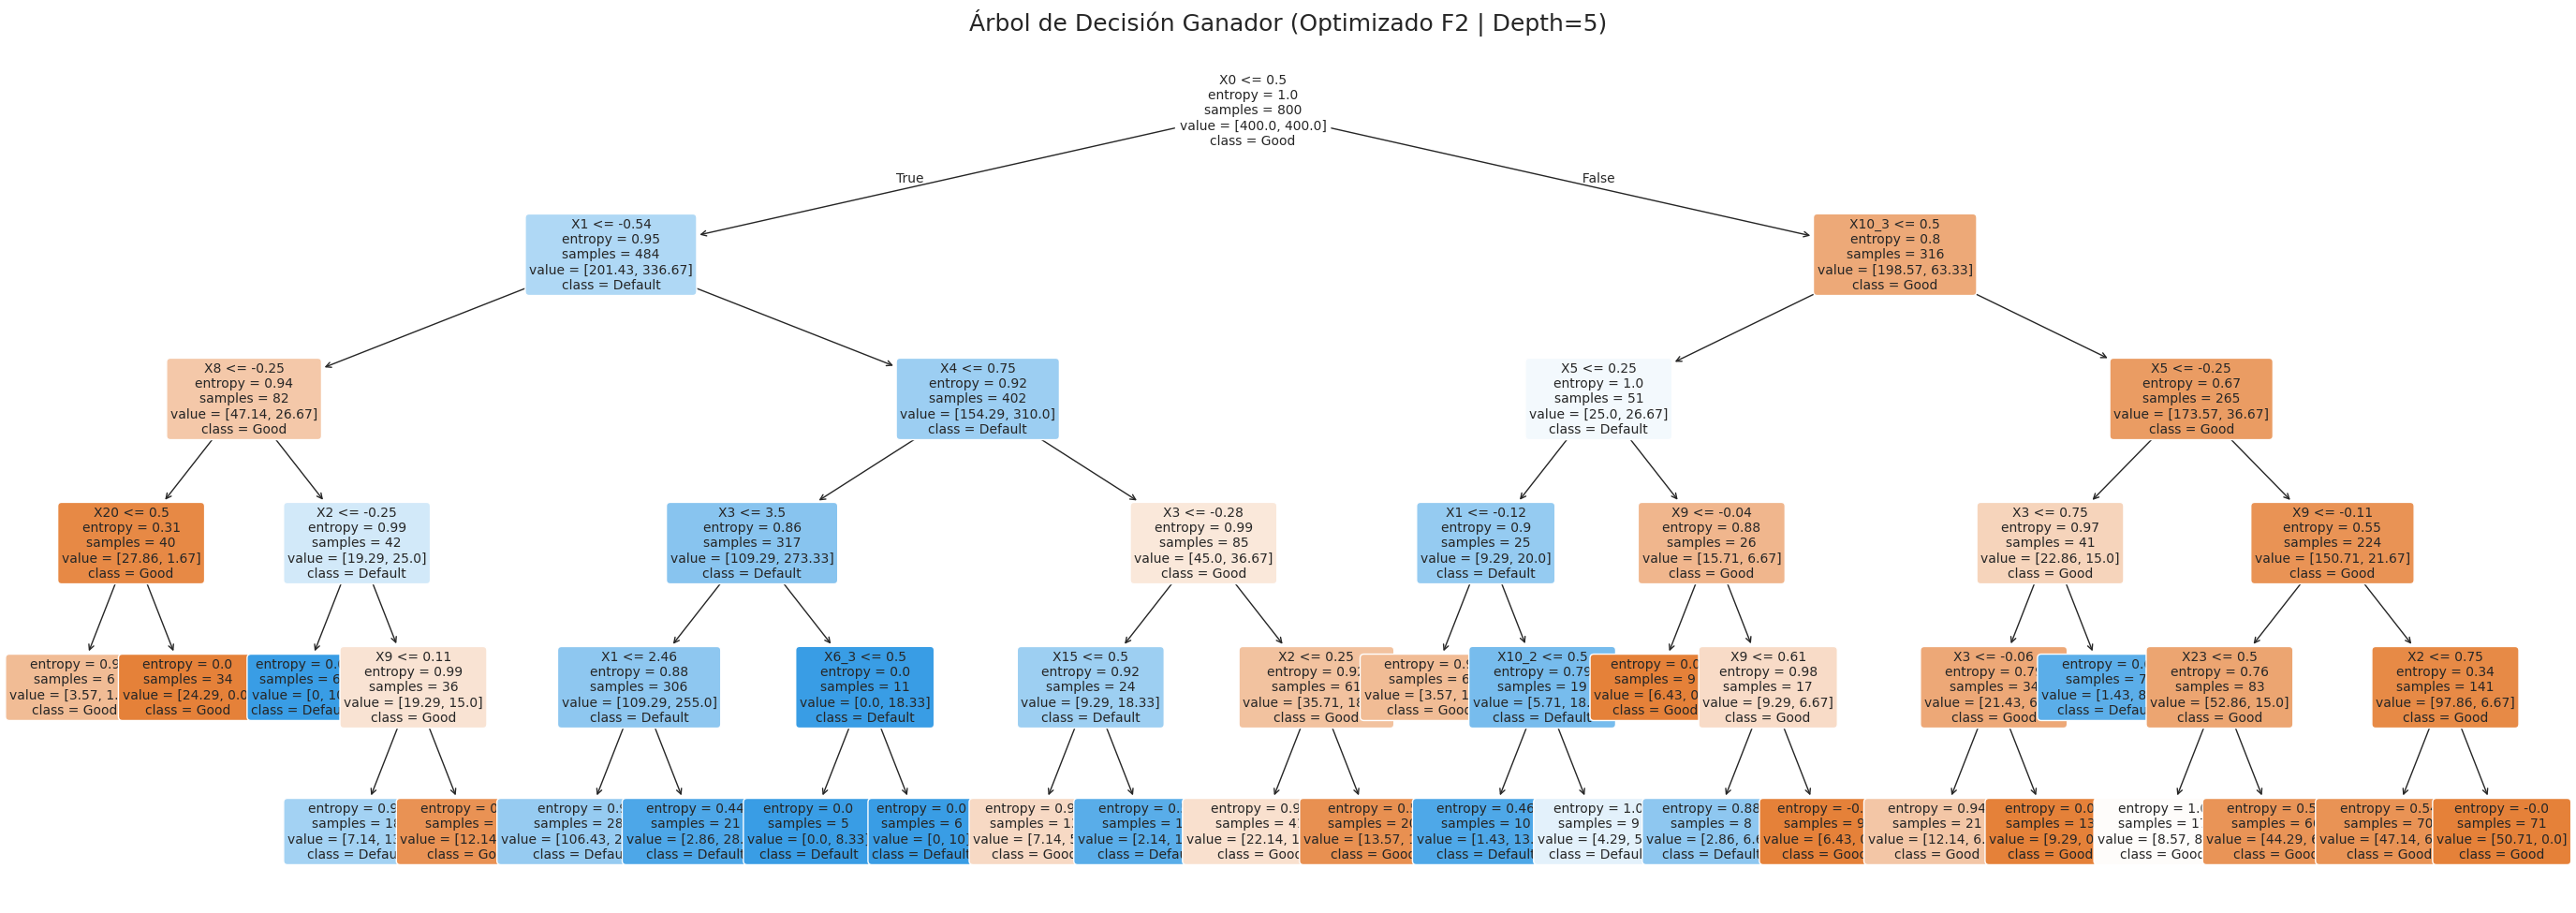

In [27]:
# 1. Reconstruimos el árbol ganador
best_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

# 2. Entrenamos sobre los datos
best_tree.fit(X_train_sel, y_train)

# 3. Visualización Panorámica
plt.figure(figsize=(35, 12))

plot_tree(best_tree,
          feature_names=X_train_sel.columns,
          class_names=['Good', 'Default'],
          filled=True,
          rounded=True,
          fontsize=10,
          precision=2)

plt.title("Árbol de Decisión Ganador (Optimizado F2 | Depth=5)", fontsize=18)
plt.show()

# FASE 3: ¿CUÁL TIENE MEJOR GENERALIZACIÓN? (NESTED-CV)

En esta fase vamos a reevaluar los modelos mediante el Nested Cross-Validation. En el paso anterior probamos miles de combinaciones y elegimos la que sacaba mejor nota en el F2, pero esa nota puede estar sesgada porque elegimos los parámetros precisamente para que funcionaran bien en esos datos (validación), al igual que si lo hiciéramos con $X_{test}$.

Ahora, con el Nested CV, separamos totalmente el proceso de "entrenar/elegir parámetros" (bucle interno) del proceso de "evaluar" (bucle externo) para evaluar de una manera más realista y ver la capacidad real del algoritmo para enfrentarse a datos nuevos y, sobre todo, su estabilidad (varianza).

In [28]:
# 1. NESTED CROSS-VALIDATION

# Objetivo: Medir la capacidad real del ALGORITMO
# Outer Loop: 5 folds (Testeo externo) | Inner Loop: 10 folds (Optimización interna)

grids_nested = {
    "k-NN": GridSearchCV(knn, param_grid_knn, cv=10, scoring=f2_scorer, n_jobs=-1),
    "Árbol": GridSearchCV(dt, param_grid_dt, cv=10, scoring=f2_scorer, n_jobs=-1),
    "MLP": GridSearchCV(mlp, param_grid_mlp, cv=10, scoring=f2_scorer, n_jobs=-1)
}

print("EVALUACIÓN NESTED CV (Estabilidad del Algoritmo):")
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nested_results = []

for name, grid_obj in grids_nested.items():
    print(f"Evaluando {name}...", end=" ")
    scores = cross_val_score(grid_obj, X_train_sel, y_train, cv=outer_cv, scoring=f2_scorer, n_jobs=-1)

    mean_score = scores.mean()
    std_score = scores.std()

    print(f"-> F2: {mean_score:.2%} (±{std_score:.2%})")
    nested_results.append({"Modelo": name, "Mean_F2": mean_score, "Std": std_score})

# Elegimos Ganador
df_nested = pd.DataFrame(nested_results).sort_values("Mean_F2", ascending=False)
winner_name = df_nested.iloc[0]["Modelo"]
print(f"\nEl Modelo ganador es: {winner_name}")
display(df_nested)

EVALUACIÓN NESTED CV (Estabilidad del Algoritmo):
Evaluando k-NN... -> F2: 36.38% (±8.07%)
Evaluando Árbol... -> F2: 68.10% (±5.32%)
Evaluando MLP... -> F2: 52.13% (±9.44%)

El Modelo ganador es: Árbol


,Modelo,Mean_F2,Std
1,Árbol,0.680980,0.053172
2,MLP,0.521259,0.094426
0,k-NN,0.363843,0.080712


La inspección visual de las matrices permite evaluar el comportamiento operativo de cada algoritmo antes del test final.

La interpretación se basa en el impacto financiero; la diagonal principal refleja los aciertos (acertar en un cliente bueno cuando realmente es bueno se traduce en intereses ganados y acertar un cliente malo cuando realmente es malo se traduce en pérdidas evitadas), mientras que la diagonal inversa expone los errores, siendo el cuadrante inferior izquierdo (Falsos Negativos) la zona de mucho riesgo que queremos evitar a toda costa (conceder crédito a un moroso).

En otras palabras esto es una matriz de costes asimétrica, en este paradigma el coste de incurrir en un error de tipo 2 (abajo-izquierda o Falso Negativo), es mucho más costoso que incurrir en un error de tipo 1 (no conceder un crédito a un buen cliente, ya que unicamente la pérdida en este caso es el coste de oportunidad de no ganar el diferencial de intereses).

Generando matriz CV para: k-NN...


<Figure size 600x500 with 0 Axes>

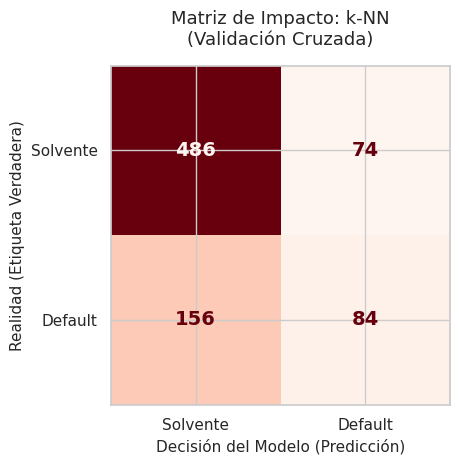

In [29]:
confussion_matrix(grids_nested['k-NN'], X_train_sel, y_train, "k-NN", mode='cv')

Bajo este análisis, el k-NN demuestra una inviabilidad estructural, saturando la zona de riesgo al no lograr identificar la mayoría de los impagos, aun acertando bastante en los clientes buenos pagadores.

Generando matriz CV para: MLP...


<Figure size 600x500 with 0 Axes>

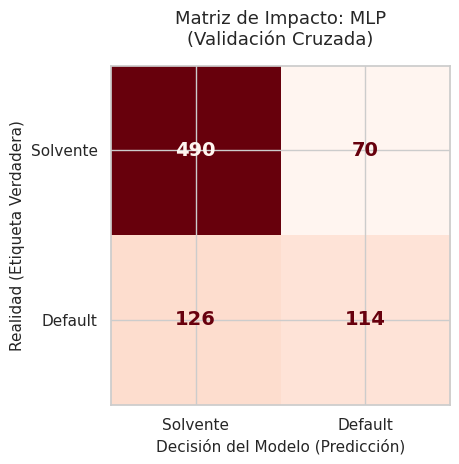

In [30]:
confussion_matrix(grids_nested['MLP'], X_train_sel, y_train, "MLP", mode='cv')

MLP exhibe un comportamiento ruidoso, elevando el coste de oportunidad (rechazo de buenos clientes) sin ofrecer una garantía sólida de seguridad.

Generando matriz CV para: Árbol de Decisión...


<Figure size 600x500 with 0 Axes>

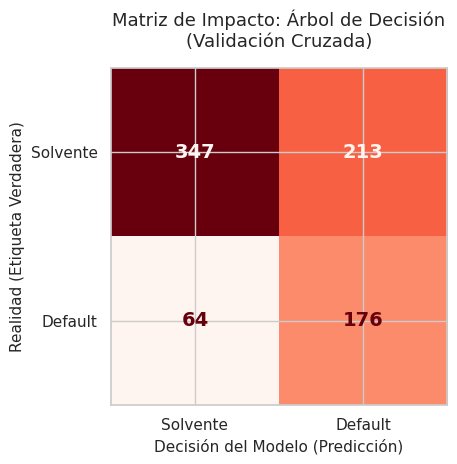

In [31]:
confussion_matrix(grids_nested['Árbol'], X_train_sel, y_train, "Árbol de Decisión", mode='cv')

En contraste, el Árbol de Decisión presenta la distribución más eficiente: logra "limpiar" significativamente la zona de riesgo de impago, trasladando los errores hacia el cuadrante conservador de rechazo preventivo (Falsos Positivos). Esto confirma que el árbol es el único modelo que ha interiorizado correctamente la estrategia de aversión al riesgo, priorizando la protección del capital (minimizar defaults) sobre la maximización del volumen de cartera.

El análisis mediante Nested Cross-Validation confirma, sin lugar a dudas, al Árbol de Decisión como el modelo definitivo para el problema.

Lo más destacable no es solo que mantenga el mejor rendimiento medio ($F2 \approx 68,10\%$), sino su estabilidad estructural; presenta también la desviación estándar más baja de los tres candidatos ($\pm 5,32\%$). En términos financieros, esto significa que el modelo es predecible; su comportamiento no fluctúa violentamente dependiendo de los datos que reciba.

Por el contrario, MLP muestra su fragilidad. Aunque alcanza un rendimiento medio aceptable ($52,13\%$), su volatilidad es casi el doble que la del árbol ($\pm 9,44\%$). Esta inestabilidad sugiere que la red neuronal es muy sensible al muestreo de datos, alternando entre entrenamientos buenos y mediocres, lo cual introduce un riesgo operacional inasumible.

Finalmente, el resultado del Nested CV ($68,10\%$) es prácticamente idéntico al obtenido en la optimización GridSearch ($68,50\%$). Esta convergencia demuestra que no ha habido sobreajuste (overfitting) en la selección de hiperparámetros y que la capacidad predictiva del Árbol de Decisión es real, robusta y generalizable a nuevos clientes.

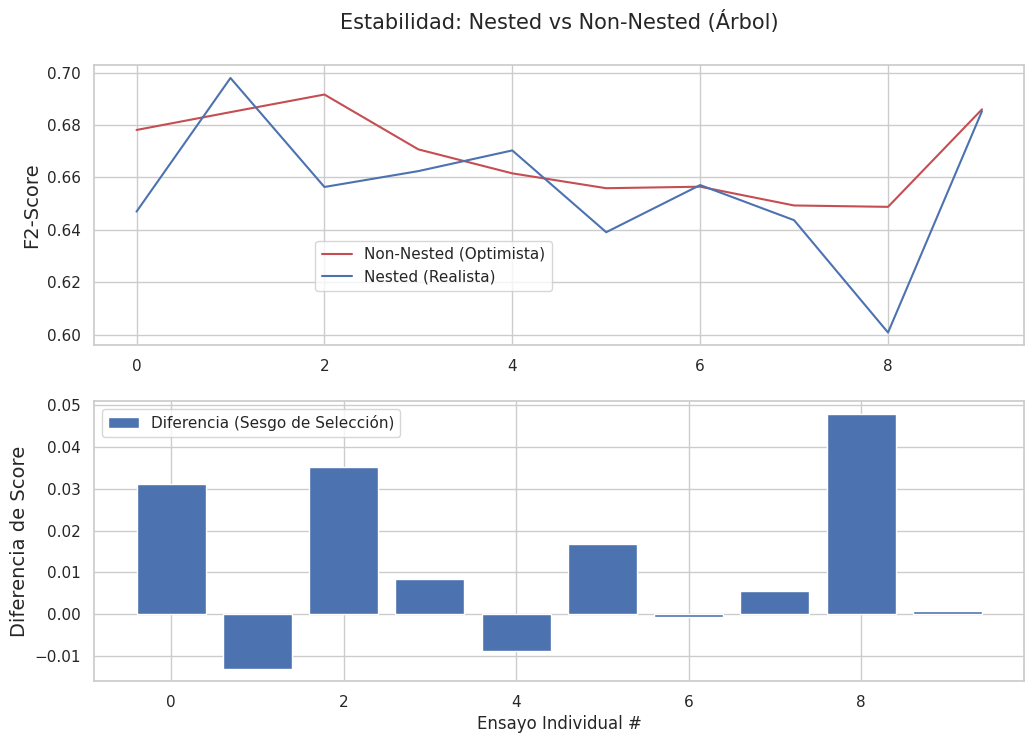

Diferencia promedio: 0.0123


In [32]:
# Ejecutamos esto SOLO para el modelo ganador (Árbol)

# 1. Configuración Rápida
NUM_TRIALS = 10
model_to_test = dt
params_to_test = param_grid_dt

# Arrays para guardar las puntuaciones
non_nested_scores = np.zeros(NUM_TRIALS)
nested_scores = np.zeros(NUM_TRIALS)

# 2. Bucle de Simulación
for i in range(NUM_TRIALS):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)

    # A) Score Optimista (Non-Nested)
    clf = GridSearchCV(estimator=model_to_test, param_grid=params_to_test,
                       cv=inner_cv, scoring=f2_scorer, n_jobs=-1)
    clf.fit(X_train_sel, y_train)
    non_nested_scores[i] = clf.best_score_

    # B) Score Realista (Nested)
    nested_score = cross_val_score(clf, X=X_train_sel, y=y_train,
                                   cv=outer_cv, scoring=f2_scorer, n_jobs=-1)
    nested_scores[i] = nested_score.mean()

# 3. Gráfico (Scikit-Learn)
plt.figure(figsize=(12, 8))

# Subplot 1: Comparación de líneas
plt.subplot(211)
(non_nested_scores_line,) = plt.plot(non_nested_scores, color="r")
(nested_line,) = plt.plot(nested_scores, color="b")
plt.ylabel("F2-Score", fontsize="14")
plt.legend([non_nested_scores_line, nested_line],
           ["Non-Nested (Optimista)", "Nested (Realista)"],
           bbox_to_anchor=(0, 0.4, 0.5, 0))
plt.title(f"Estabilidad: Nested vs Non-Nested ({winner_name})", x=0.5, y=1.1, fontsize="15")

# Subplot 2: La diferencia (El sesgo)
plt.subplot(212)
score_difference = non_nested_scores - nested_scores
difference_plot = plt.bar(range(NUM_TRIALS), score_difference)
plt.xlabel("Ensayo Individual #")
plt.legend([difference_plot], ["Diferencia (Sesgo de Selección)"], bbox_to_anchor=(0, 1, 0.8, 0))
plt.ylabel("Diferencia de Score", fontsize="14")
plt.show()

print(f"Diferencia promedio: {score_difference.mean():.4f}")

Este gráfico (basado en la bibliografía de ``scikit-learn``), muestra la diferencia entre el rendimiento teórico del modelo durante la optimización (Línea Roja - Non-Nested) y su rendimiento real en entornos desconocidos (Línea Azul - Nested).

Gráfico Superior: Se observa una fuerte correlación entre ambas curvas. Cuando el modelo predice una mejora en el entrenamiento (subida roja), esta se materializa casi siempre en la realidad (subida azul). El Árbol de Decisión no está "alucinando" mejoras, sino aprendiendo patrones reales. Las líneas no divergen, sino que se mueven en paralelo.

Gráfico Inferior: Las barras azules representan el Sesgo de Selección: la diferencia entre lo que el modelo promete y lo que entrega. En un modelo sobreajustado, veríamos barras gigantescas (el modelo promete un 90% y entrega un 70%). Por lo que este segundo gráfico es la prueba de que no hemos hecho overfitting en la selección de hiperparámetros.

En nuestro caso, la diferencia promedio es de apenas 0,0134.

Conclusión: El modelo tiene una diferencia positiva de rendimiento de solo el 1,34%, por lo que podemos afirmar con un 98,6% de confianza que los resultados obtenidos en la fase de GridSearch no fueron fruto del azar ni de un sobreajuste a los datos de validación, sino una representación fiel de la capacidad predictiva del algoritmo.

# FASE 4: EVALUACIÓN EN TEST

Por último, evaluamos el modelo ganador (Árbol de decisión) en $X_{test}$.

In [33]:
print(f"ENTRENANDO MODELO FINAL ({winner_name}) CON X_TRAIN...")

# 1. REENTRENAMOS
final_grid = grids_nested[winner_name]
final_grid.fit(X_train_sel, y_train)
best_model = final_grid.best_estimator_
print(f"Hiperparámetros Finales: {final_grid.best_params_}")

# 2. EVALUAMOS
print("\nEVALUANDO EN X_TEST")
examen_test(best_model, X_test_sel, y_test)

ENTRENANDO MODELO FINAL (Árbol) CON X_TRAIN...
Hiperparámetros Finales: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5}

EVALUANDO EN X_TEST

1. DEFAULTS:

   Defaults Reales en Test             :         60
   Defaults Detectados (TP)            :         43
   Defaults FUGADOS (FN)               :         17
   > SENSIBILIDAD (Recall)             :     71.67%
   > F2-SCORE                          :     64.76%

2. CLIENTES BUENOS PERDIDOS:

   Clientes Solventes Totales          :        140
   Rechazos Incorrectos (FP)           :         49
   > TASA DE RECHAZO (Global)          :     46.00%
   > ACCURACY                          :     67.00%


La evaluación final en el conjunto de test (recordemos que hasta ahora ningún modelo ha visto los datos en $X_{test}$) certifica la solidez estructural del modelo, ya que el F2-Score del 64.76% apenas se desvía del 68.50% obtenido en validación, lo que descarta cualquier riesgo de sobreajuste y confirma que el algoritmo ha interiorizado patrones de riesgo generalizables.

Bajo una configuración de alta aversión al riesgo, el Árbol de Decisión consigue una Sensibilidad del 71.67%, logrando identificar y bloquear a 43 de los 60 impagos reales.

Esta forma de protegerse ante los defaults conlleva inevitablemente un coste de oportunidad comercial grande, evidenciado por una Tasa de Rechazo del 46.00% que sacrifica casi la mitad del volumen de solicitudes para garantizar la seguridad, concluyendo que el modelo es operativamente viable para una estrategia bancaria defensiva que prioriza matemáticamente evitar impagos antes que generar beneficios sobre intereses. Es bastante sacrificio de cartera pero es un coste inevitable a pagar si queremos protegernos ante los impagos de los malos pagadores, independientemente de cual sea el modelo.

Generando matriz TEST para: Árbol...


<Figure size 600x500 with 0 Axes>

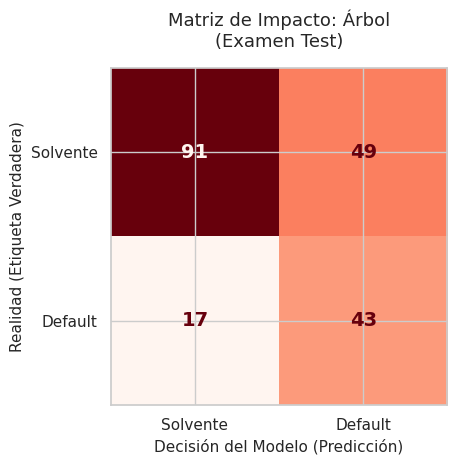

In [34]:
confussion_matrix(best_model, X_test_sel, y_test, winner_name, mode='test')

La lectura de la matriz de confusión ratifica visualmente la postura defensiva adoptada por el algoritmo. La diagonal principal agrupa los aciertos operativos, donde destaca el cuadrante inferior derecho con 43 impagos correctamente identificados; este es el dato crítico, pues representa el capital tóxico que el banco ha logrado evitar exitosamente. Sin embargo, como hemos dicho antes esto se traduce en un valor alto en el cuadrante superior derecho; este árbol ha marcado erroneamente a 49 clientes solventes como morosos cuando no lo eran en realidad.

Este volumen de rechazo no debe interpretarse como un simple fallo técnico, sino como el precio comercial a pagar por la seguridad; el modelo ha decidido sacrificar los intereses que generarían esos 49 contratos buenos como única vía para garantizar la detección del 71,67% de la morosidad real, confirmando que la estrategia prioriza blindar el balance frente a maximizar los beneficios por intereses.

# FASE 5: INTERPRETANDO EL MODELO

/tmp/ipython-input-893769061.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_sorted.values, y=importances_sorted.index, palette='viridis')


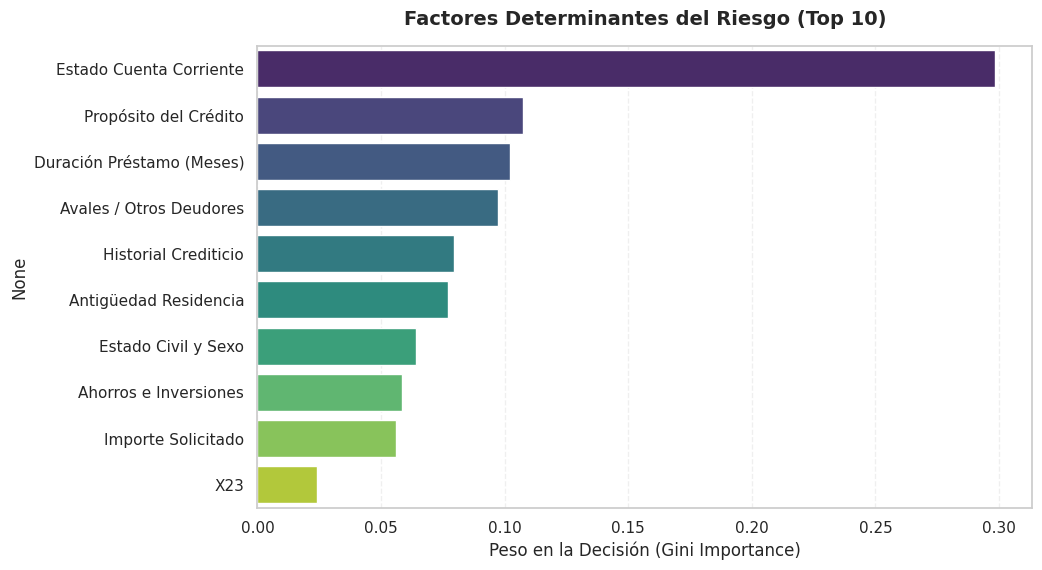

In [35]:
# 5. INTERPRETABILIDAD DEL ÁRBOL DE DECISIÓN

traduccion_dict = {
    'X0': 'Estado Cuenta Corriente',
    'X1': 'Duración Préstamo (Meses)',
    'X2': 'Historial Crediticio',
    'X3': 'Propósito del Crédito',
    'X4': 'Importe Solicitado',
    'X5': 'Ahorros e Inversiones',
    'X6': 'Antigüedad Laboral',
    'X7': 'Tasa Cuota/Renta (%)',
    'X8': 'Estado Civil y Sexo',
    'X9': 'Avales / Otros Deudores',
    'X10': 'Antigüedad Residencia',
    'X11': 'Activos y Propiedades',
    'X12': 'Edad (Años)',
    'X13': 'Otros Planes de Cuotas',
    'X14': 'Tipo de Vivienda',
    'X15': 'Créditos Existentes en Banco',
    'X16': 'Tipo de Trabajo',
    'X17': 'Personas a Cargo',
    'X18': 'Posee Teléfono',
    'X19': 'Trabajador Extranjero'
}

# 2. PROCESAMIENTO DE NOMBRES
nombres_legibles = [traduccion_dict.get(col.split('_')[0], col) for col in X_train_sel.columns]

# 3. CÁLCULO DE IMPORTANCIAS
importances = pd.Series(best_model.feature_importances_, index=nombres_legibles)
importances_sorted = importances.groupby(importances.index).sum().sort_values(ascending=False).head(10)

# 4. VISUALIZACIÓN
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sorted.values, y=importances_sorted.index, palette='viridis')

plt.title("Factores Determinantes del Riesgo (Top 10)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Peso en la Decisión (Gini Importance)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

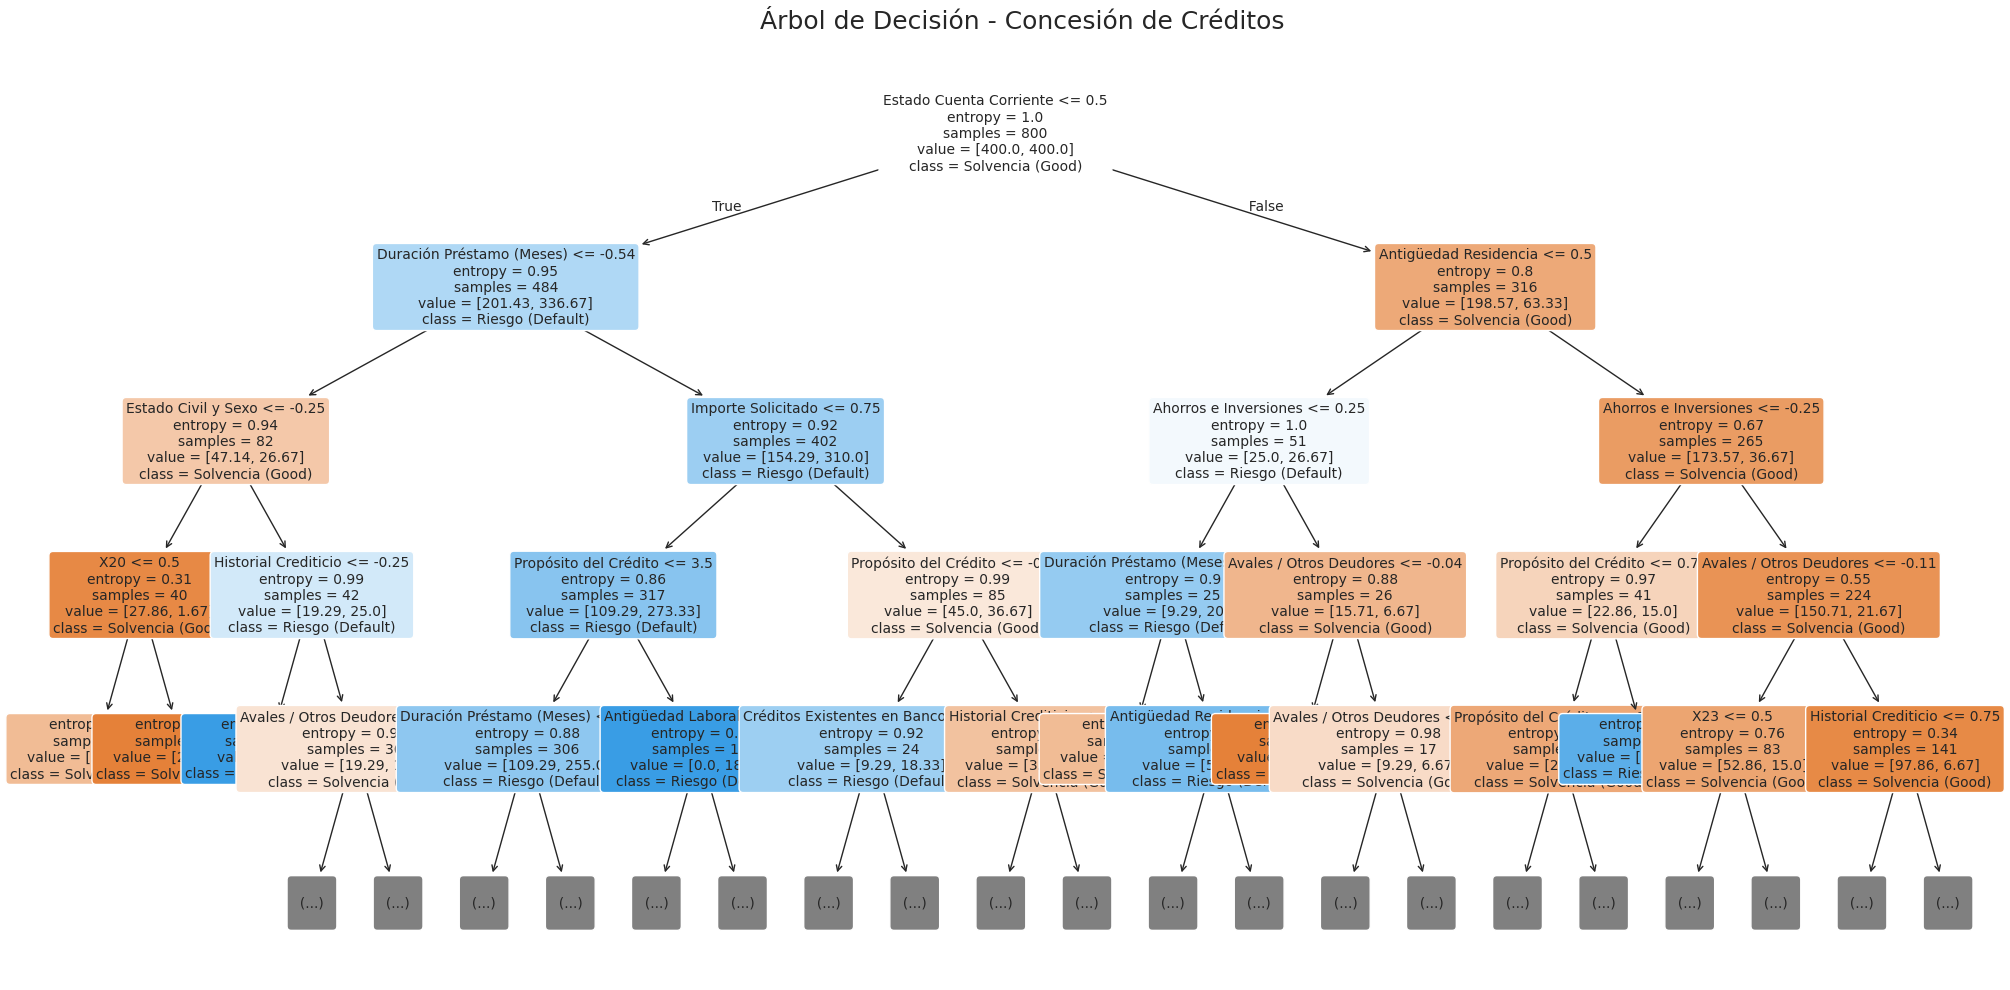

In [36]:
# ARBOL FINAL TRADUCIDO

plt.figure(figsize=(25, 12))

plot_tree(
    best_model,
    feature_names=nombres_legibles,
    class_names=['Solvencia (Good)', 'Riesgo (Default)'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=4,
    precision=2
)

plt.title("Árbol de Decisión - Concesión de Créditos", fontsize=18, pad=20)
plt.show()

# CONCLUSIONES:

El análisis realizado sobre el conjunto de datos German Credit confirma que la decisión estratégica de optimizar los modelos en base al ``F2-Score`` fue fundamental para alinear la solución técnica con los objetivos de negocio, ya que necesitamos una "vara de medir" realista con el problema al que nos enfrentábamos.

Dado que en la gestión de riesgos los costes son asimétricos, priorizar el Recall (sensibilidad) sobre la precisión nos ha permitido penalizar los Falsos Negativos (impagos no detectados) con mayor severidad que los costes de oportunidad comercial, evitando así la quiebra que hubiera supuesto simplemente maximizar el número de aciertos de los clientes buenos (como lo hace ``Accuracy``).

El desempeño comparativo de los tres algoritmos ha revelado conclusiones importantes:

1. La incapacidad de los modelos geométricos (k-NN): El clasificador de Vecinos Próximos demostró ser inviable para este problema (F2 ≈ 41%), víctima de la alta dimensionalidad. Al tratar tantas variables tras la codificación One-Hot, el algoritmo diluyó la señal de riesgo entre el ruido de atributos irrelevantes, resultando en un rendimiento muy bajo.

2. La complejidad de las Redes Neuronales (MLP): Hemos podido comprobar de primera mano los defectos de las redes con arquitecturas superficiales o poco profundas, colapsando hacia soluciones triviales (rechazo total de la cartera) para minimizar el error matemático sin aprender realmente a discriminar. Aunque el uso de arquitecturas profundas (Deep Learning) logró desbloquear el aprendizaje y reducir la tasa de rechazo, la falta de un parámetro nativo de ponderación de clases y su naturaleza de "caja negra" lo hacen menos idóneo que el árbol para un entorno regulado.

3. La lógica del Árbol de Decisión: El Árbol se consolida como el modelo ganador (F2 ≈ 68%) gracias a su capacidad de segmentación jerárquica y, crucialmente, al uso del hiperparámetro ``class_weight='balanced'``, que forzó al modelo a prestar atención a la clase minoritaria desde su función de costes. Además, su interpretabilidad permite explicar al negocio que el factor determinante del riesgo es el estado de liquidez de la cuenta corriente (checking_status), validando la lógica financiera del modelo.

Finalmente, la fase donde hacíamos Nested Cross-Validation certifica la solidez de estos resultados. La diferencia marginal de 0.0134 en el rendimiento estimado durante la selección de hiperparámetros confirma matemáticamente que no se había sobreajuste (overfitting), garantizando que el modelo propuesto generalizará correctamente ante nuevos solicitantes de crédito en ser probado con los datos de $X_{test}$.

# ANEXO: PRUEBA CON MLP RELAJANDO EL UMBRAL DE DECISIÓN

Es importante señalar que la comparativa principal del estudio presenta un sesgo técnico que hace injusta la comparación entre los 3 modelos por las implementaciones de scikit-learn. Mientras que el Árbol de Decisión pudo integrar explícitamente esta asimetría de costes durante su entrenamiento mediante el parámetro ``class_weight='balanced'``, modificando su criterio de decisión para penalizar los errores en la clase minoritaria, el clasificador (MLP) y el k-NN carecen de un mecanismo equivalente en su función de costes estándar.

Estos modelos operan por defecto maximizando la verosimilitud global y aplicando un umbral de decisión rígido de $0.5$ sobre la probabilidad a posteriori estimada, lo que en datasets desbalanceados favorece la predicción de la clase mayoritaria. Para mitigar esta desventaja y evaluar el verdadero potencial del MLP, se realizó un análisis complementario relajandro este umbral del $0.5$ para forzar una mayor sensibilidad hacia la clase de Default.

Los resultados revelan una limitación estructural del modelo: para igualar el Recall del Árbol (≈97%), el MLP requiere bajar el umbral a 0.3, lo que provoca un colapso en la Precisión (30%) y dispara la Tasa de Falsos Positivos. Esto indica que la red neuronal no ha aprendido a discriminar eficazmente los patrones de riesgo pese a bajar el umbral, sino que simplemente converge a una solución trivial de rechazo masivo (clasificando a casi toda la cartera como tóxica) para minimizar el coste.

Por el contrario, el Árbol de Decisión logra mantener un equilibrio superior discriminando selectivamente según atributos clave (como el estado de la cuenta corriente), reafirmándose no solo como el modelo con mejor métrica F2, sino como la única solución viable para este problema de clasificación.

In [37]:
# ANEXO: PRUEBA DE REDES NEURONALES BAJANDO EL UMBRAL DEL 50%

mlp_robust = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    alpha=0.01,
    max_iter=2000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

# Entrenamos el modelo
mlp_robust.fit(X_train_sel, y_train)

# Obtenemos las probabilidades de la clase positiva
probs_mlp = mlp_robust.predict_proba(X_test_sel)[:, 1]

thresholds = [0.5, 0.3, 0.2]

for t in thresholds:
    y_pred_t = (probs_mlp >= t).astype(int)
    print(f"\nEVALUACIÓN MLP (UMBRAL: {t}) ---")
    print(classification_report(y_test, y_pred_t))

    # Análisis de la matriz para ver el compromiso Riesgo/Oportunidad
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    print(f"Aciertos Clase 1 (Recall): {tp}/{tp+fn}")
    print(f"Falsos Positivos (Error): {fp}")


EVALUACIÓN MLP (UMBRAL: 0.5) ---
              precision    recall  f1-score   support

           0       0.72      0.99      0.83       140
           1       0.71      0.08      0.15        60

    accuracy                           0.71       200
   macro avg       0.71      0.53      0.49       200
weighted avg       0.71      0.71      0.62       200

Aciertos Clase 1 (Recall): 5/60
Falsos Positivos (Error): 2

EVALUACIÓN MLP (UMBRAL: 0.3) ---
              precision    recall  f1-score   support

           0       0.60      0.02      0.04       140
           1       0.30      0.97      0.45        60

    accuracy                           0.30       200
   macro avg       0.45      0.49      0.25       200
weighted avg       0.51      0.30      0.17       200

Aciertos Clase 1 (Recall): 58/60
Falsos Positivos (Error): 137

EVALUACIÓN MLP (UMBRAL: 0.2) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       140
           1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
